# [LAB 07] 추론통계 - 5. 독립표본 T-Test

## #01. 준비작업 

### 1. 라이브러리 참조 

In [268]:
from jussam import load_data
from helpers import my_plot, my_stats
from pandas import melt, DataFrame, pivot_table

# 가설 검정 가정에 따른 검정 방법 선택을 위한 라이브러리 
from scipy.stats import ttest_ind, mannwhitneyu

# 시각화에 필요한 라이브러리 
from statannotations.Annotator import Annotator 

## #02. 예제(1) - 지혈제 효과 비교 

### 2. 데이터 가져오기 

In [269]:
df1 = load_data("styptic")
df1.head()

📚 실험 참가자를 두 그룹으로 임의 분할한 후 피부에 작은 상처를 내어 피가 흐르게 한 다음, 한 그룹에는 지혈제 B를 다른 그룹에는 지혈제 G를 투여하여 완전히 지혈될 때 까지의 시간(분)을 측정한 두 종료의 지혈제 효과를 측정한 자료 (출처: 방송통신대학교 통계학개론)


,B,G
0,8.800,9.900
1,8.900,10.000
2,8.400,9.000
3,7.900,11.100
4,8.200,9.800


### 2. 시각화를 위한 데이터 재배치 

In [270]:
df1_melt = melt(df1, var_name="group", value_name="value")
df1_melt.head()

,group,value
0,B,8.800
1,B,8.900
2,B,8.400
3,B,7.900
4,B,8.200


### 3. 데이터 분포 확인

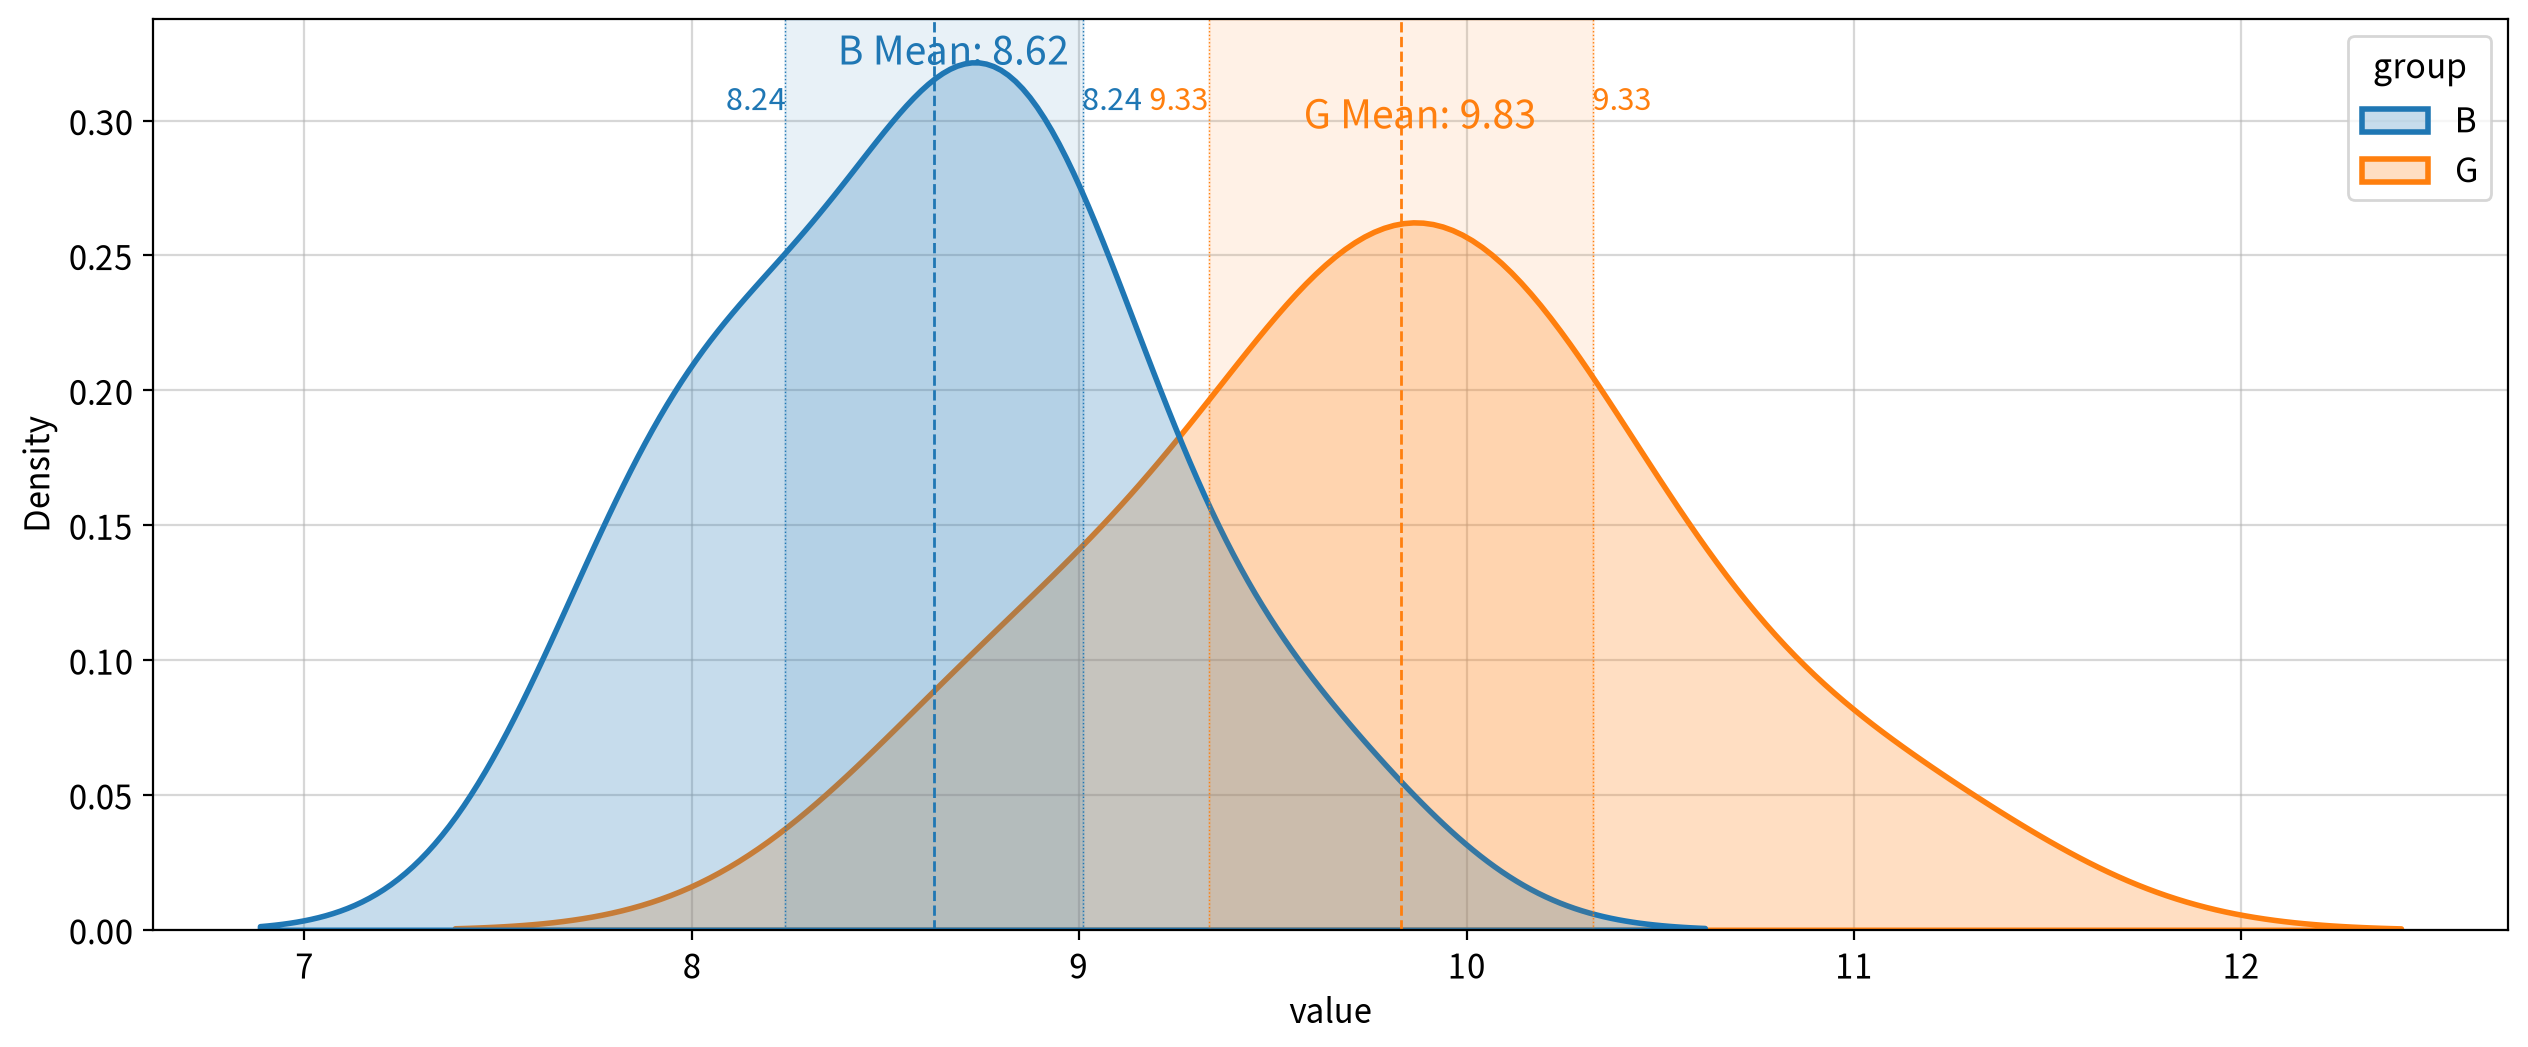

In [271]:
my_plot.kdeplot(df1_melt, x="value", hue="group", 
                fill=True, meanline=True, clevel=0.95)

### 4. 가설검정의 가정 확인 

In [272]:
my_stats.test_assumptions(df1, columns=['B', 'G'])

,test,statistic,p-value,result
field,,,,
B,normaltest,0.083,0.959,True
G,normaltest,0.201,0.904,True
Bartlett,equal_var,0.556,0.456,True


### 5. Student's T-Test 양측 검정 

In [273]:
s, p = ttest_ind(df1['B'], df1['G'], equal_var=True)
print(f"statistic: {s:.4f}, p-value: {p:.4f}")

statistic: -4.3497, p-value: 0.0004


### 6. Student's T-Test 좌측 단측 검정 

In [274]:
s, p = ttest_ind(df1['B'], df1['G'], equal_var=True,
                 alternative='less')
print(f"statistic: {s:.4f}, p-value: {p:.4f}")

statistic: -4.3497, p-value: 0.0002


### 7. Student's T-Test 우측 단측 검정 

In [275]:
s, p = ttest_ind(df1['B'], df1['G'], equal_var=True, 
                 alternative='greater')
print(f"statistic: {s:.4f}, p-value: {p:.4f}")

statistic: -4.3497, p-value: 0.9998


### 8. 가설검정 시각화 

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

B vs. G: t-test independent samples, P_val:3.862e-04 t=-4.350e+00


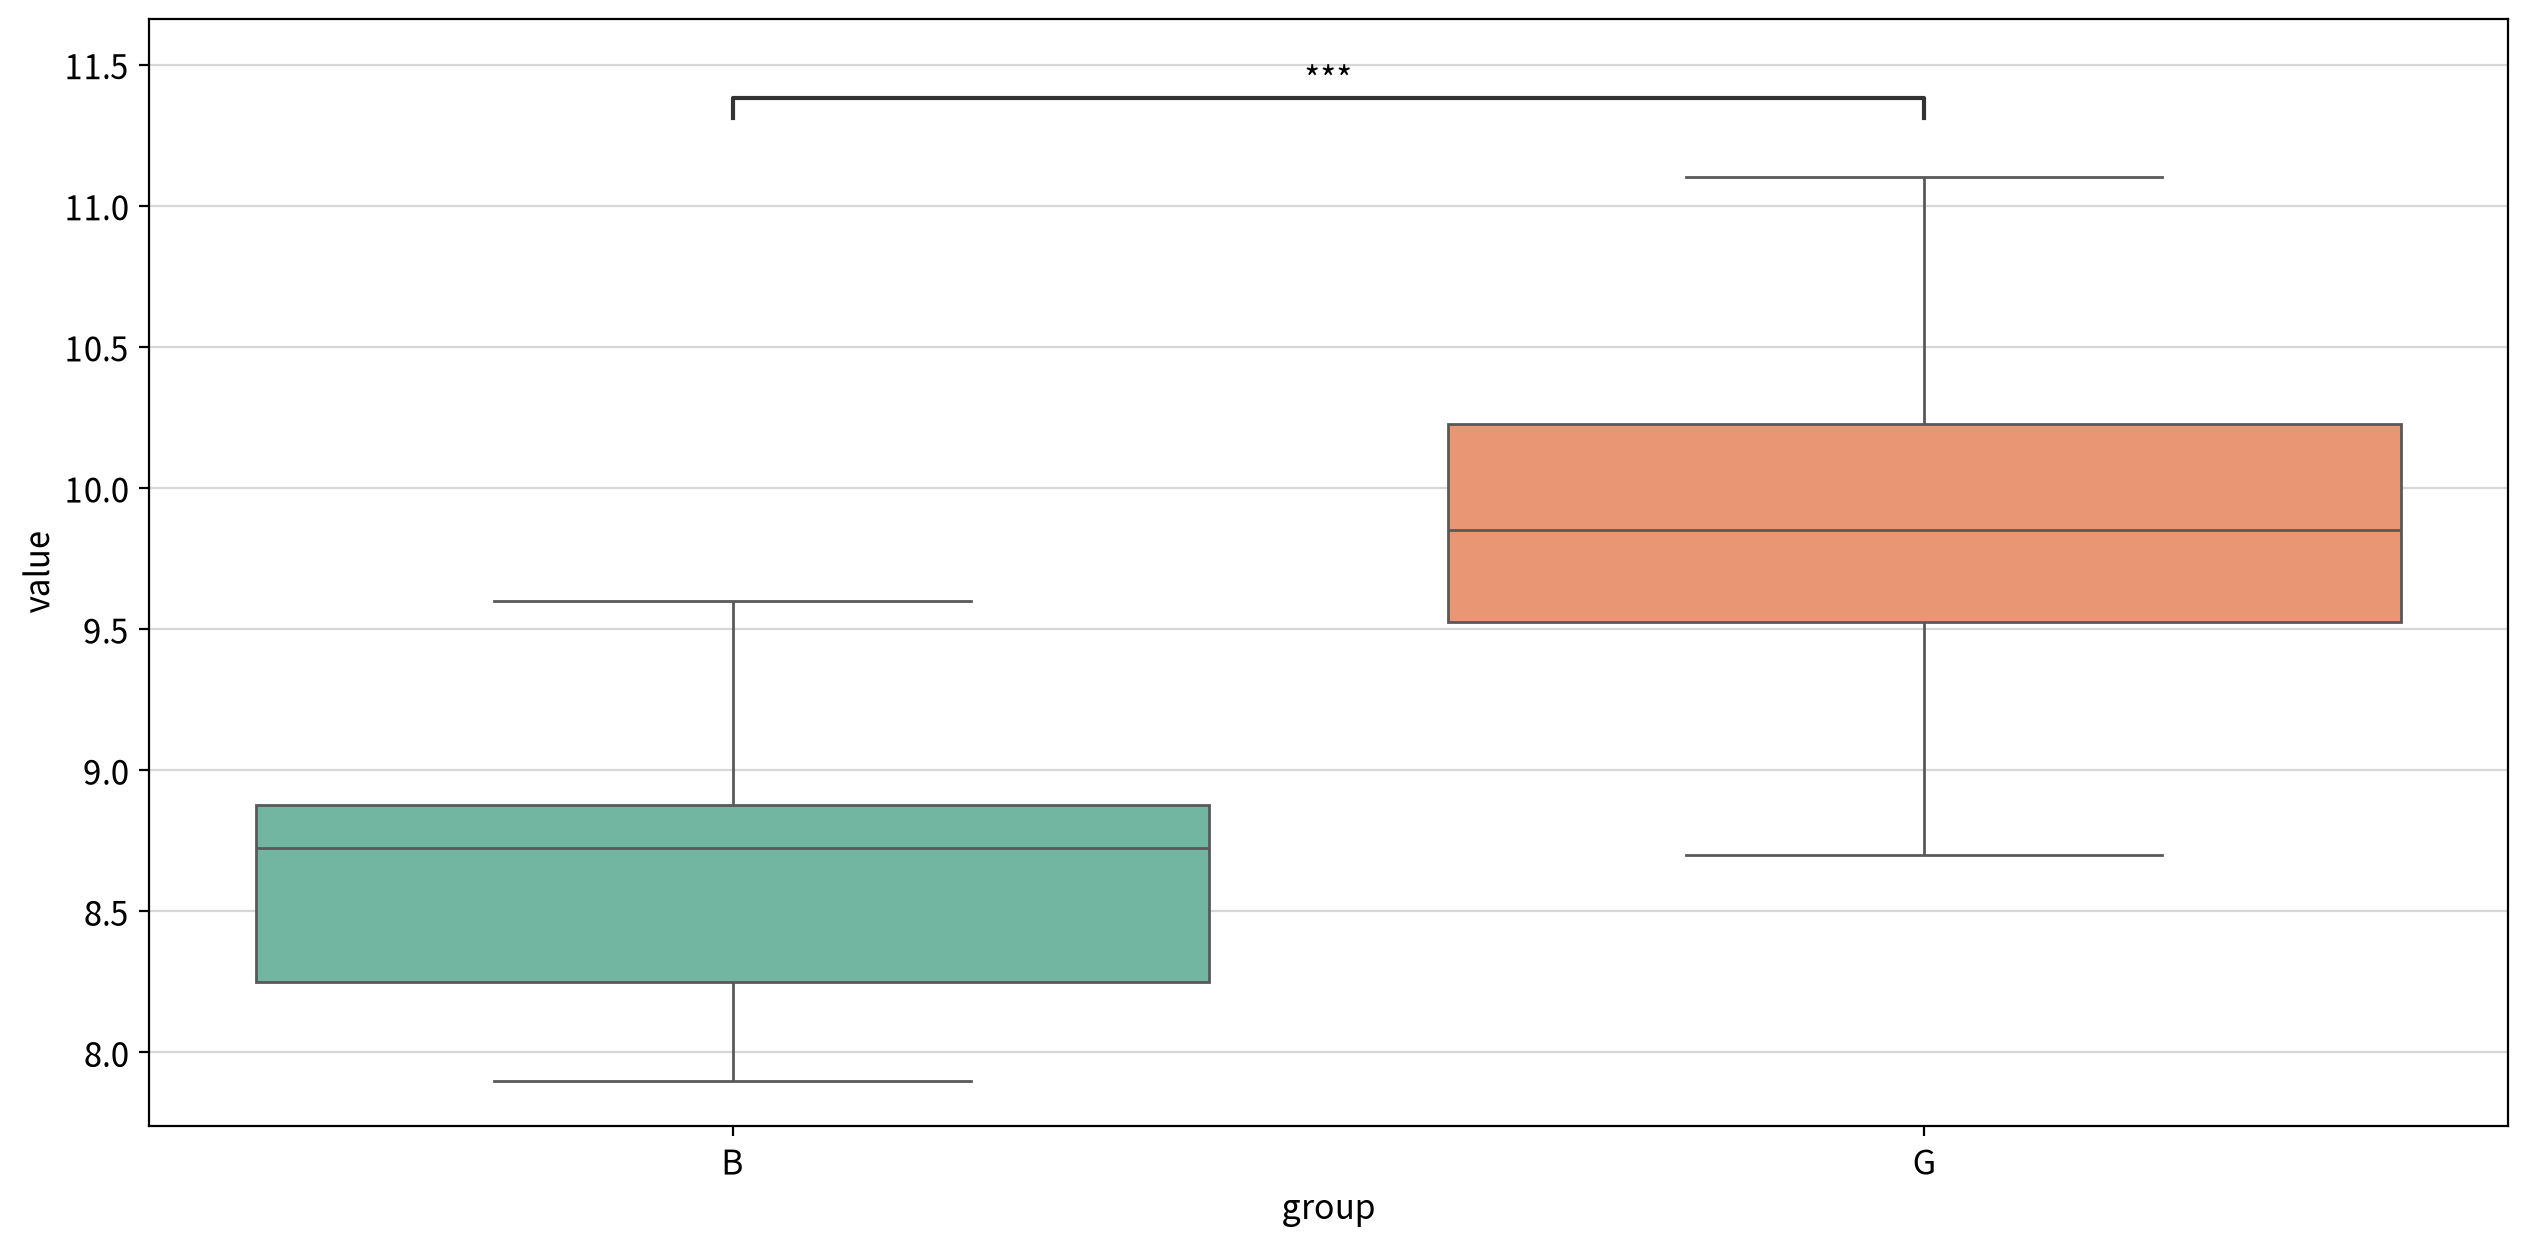

In [276]:
fig, ax = my_plot.init()
my_plot.boxplot(data=df1_melt, 
                x="group", y="value", hue="group", 
                palette="Set2", ax=ax)

# 독립표본 T검정 결과를 시각화에 추가 
annotator = Annotator(ax, 
                      data=df1_melt, 
                      x='group', 
                      y='value', 
                      pairs=[('B', 'G')]
                      )

# 가설검정 알고리즘 종류 ( 't-test_ind', 't-test_paired', 't-test_welch', 'Mann-Whitney',
# 'Mann-Whitney-gt', 'Mann-Whitney-ls', 'Levene', 'Wilcoxon', 'Kruskal' 등을 지원)

annotator.configure(test='t-test_ind')
annotator.apply_and_annotate()

my_plot.show()

## #03. 예제(2) - 인공심장 효과 측정 

### 1. 데이터 가져오기 

In [277]:
df2 = load_data("heatrate")
df2.head()

📚 두 독립적인 그룹의 심장병 환자에 대한 심장계수(cardiac index)를 측정한 데이터. `그룹1`은 심장수술을 받고 부착한 인공장기의 기능이 정상적인 사람들이고, `그룹2`는 비정상으로 판명된 사람들이다.심장계수는 수술 직후에 측정하였다. (출처: 방송통신대학교 통계학개론)


,그룹1,그룹2
0,3.840,3.970
1,2.600,2.500
2,1.190,2.700
3,2.000,3.360
4,6.200,3.550


### 2. 시각화를 위한 재배치 (Wide 타입 -> Long 타입)

In [278]:
df2_melt = melt(df2, 
                var_name="group",
                value_name="value")
df2_melt.head()

,group,value
0,그룹1,3.840
1,그룹1,2.600
2,그룹1,1.190
3,그룹1,2.000
4,그룹1,6.200


### 3. 데이터 분포 확인 

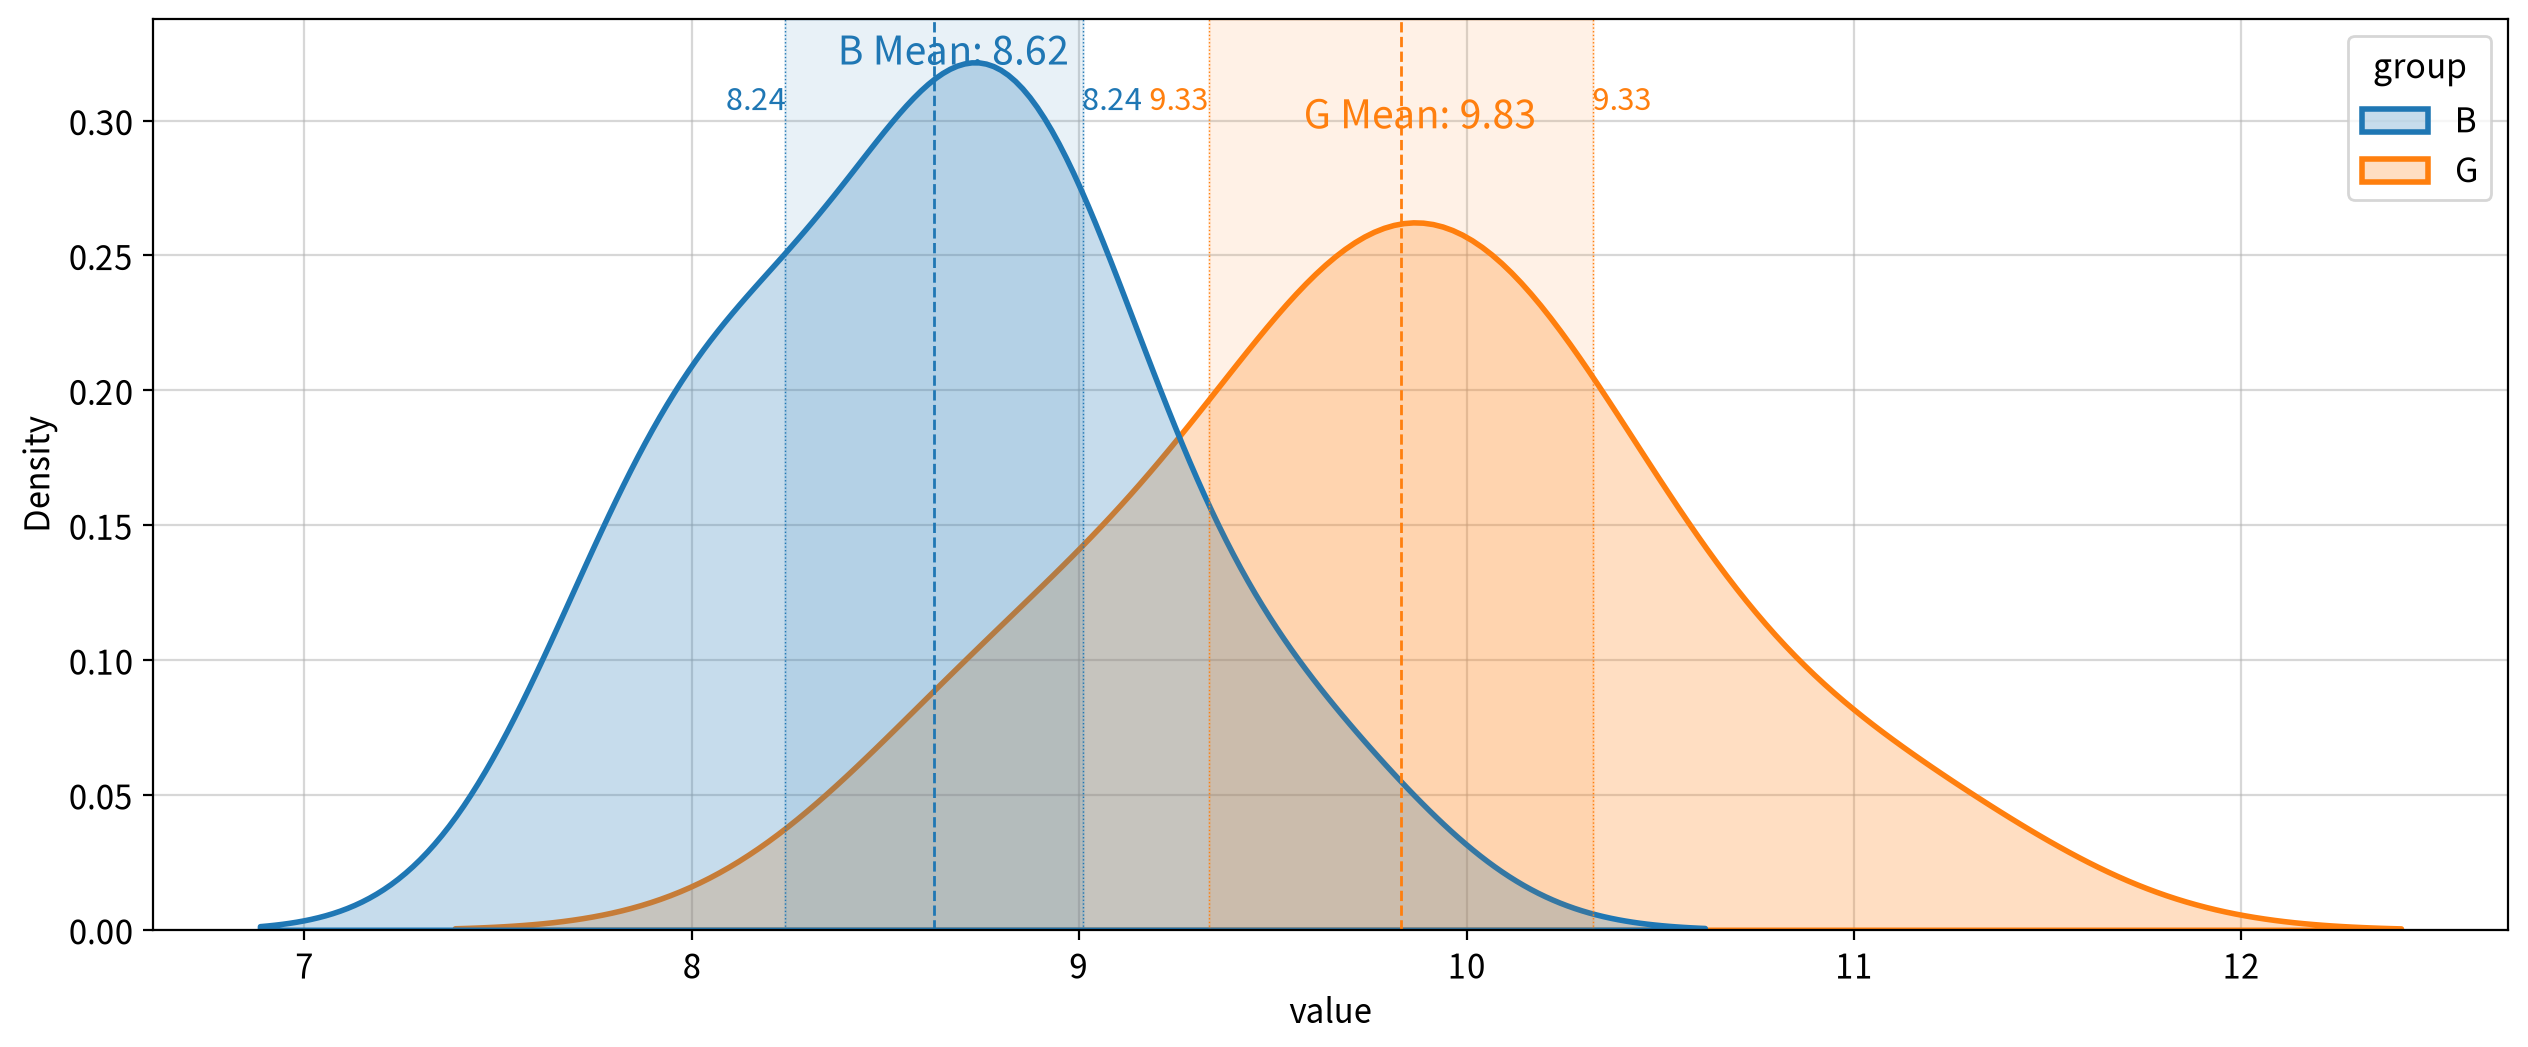

In [279]:
my_plot.kdeplot(df1_melt, x="value", hue="group", 
                fill=True, meanline=True, clevel=0.95)

### 4. 가설검정의 가정 확인 

In [280]:
my_stats.test_assumptions(df2, columns=['그룹1', '그룹2'])

,test,statistic,p-value,result
field,,,,
그룹1,normaltest,0.840,0.657,True
그룹2,normaltest,0.261,0.878,True
Bartlett,equal_var,8.029,0.005,False


### 5. Welch T-Test 양측검정 

In [281]:
s, p = ttest_ind(df2['그룹1'], df2['그룹2'], equal_var=False)
print(f"statistic: {s:.4f}, p-value: {p:.4f}")

statistic: 0.1633, p-value: 0.8742


### 6. Welch T-Test 좌측 단측검정 

In [282]:
s, p = ttest_ind(df2['그룹1'], df2['그룹2'], equal_var=False, 
                 alternative='less')
print(f"statistic: {s:.4f}, p-value: {p:.4f}")

statistic: 0.1633, p-value: 0.5629


### 7. Welch T-Test 우측 단측검정 

In [283]:
s, p = ttest_ind(df2['그룹1'], df2['그룹2'], equal_var=False, 
                 alternative='greater')
print(f"statistic: {s:.4f}, p-value: {p:.4f}")

statistic: 0.1633, p-value: 0.4371


### 8. 가설검정 시각화 

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

그룹1 vs. 그룹2: Welch's t-test independent samples, P_val:8.742e-01 t=1.633e-01


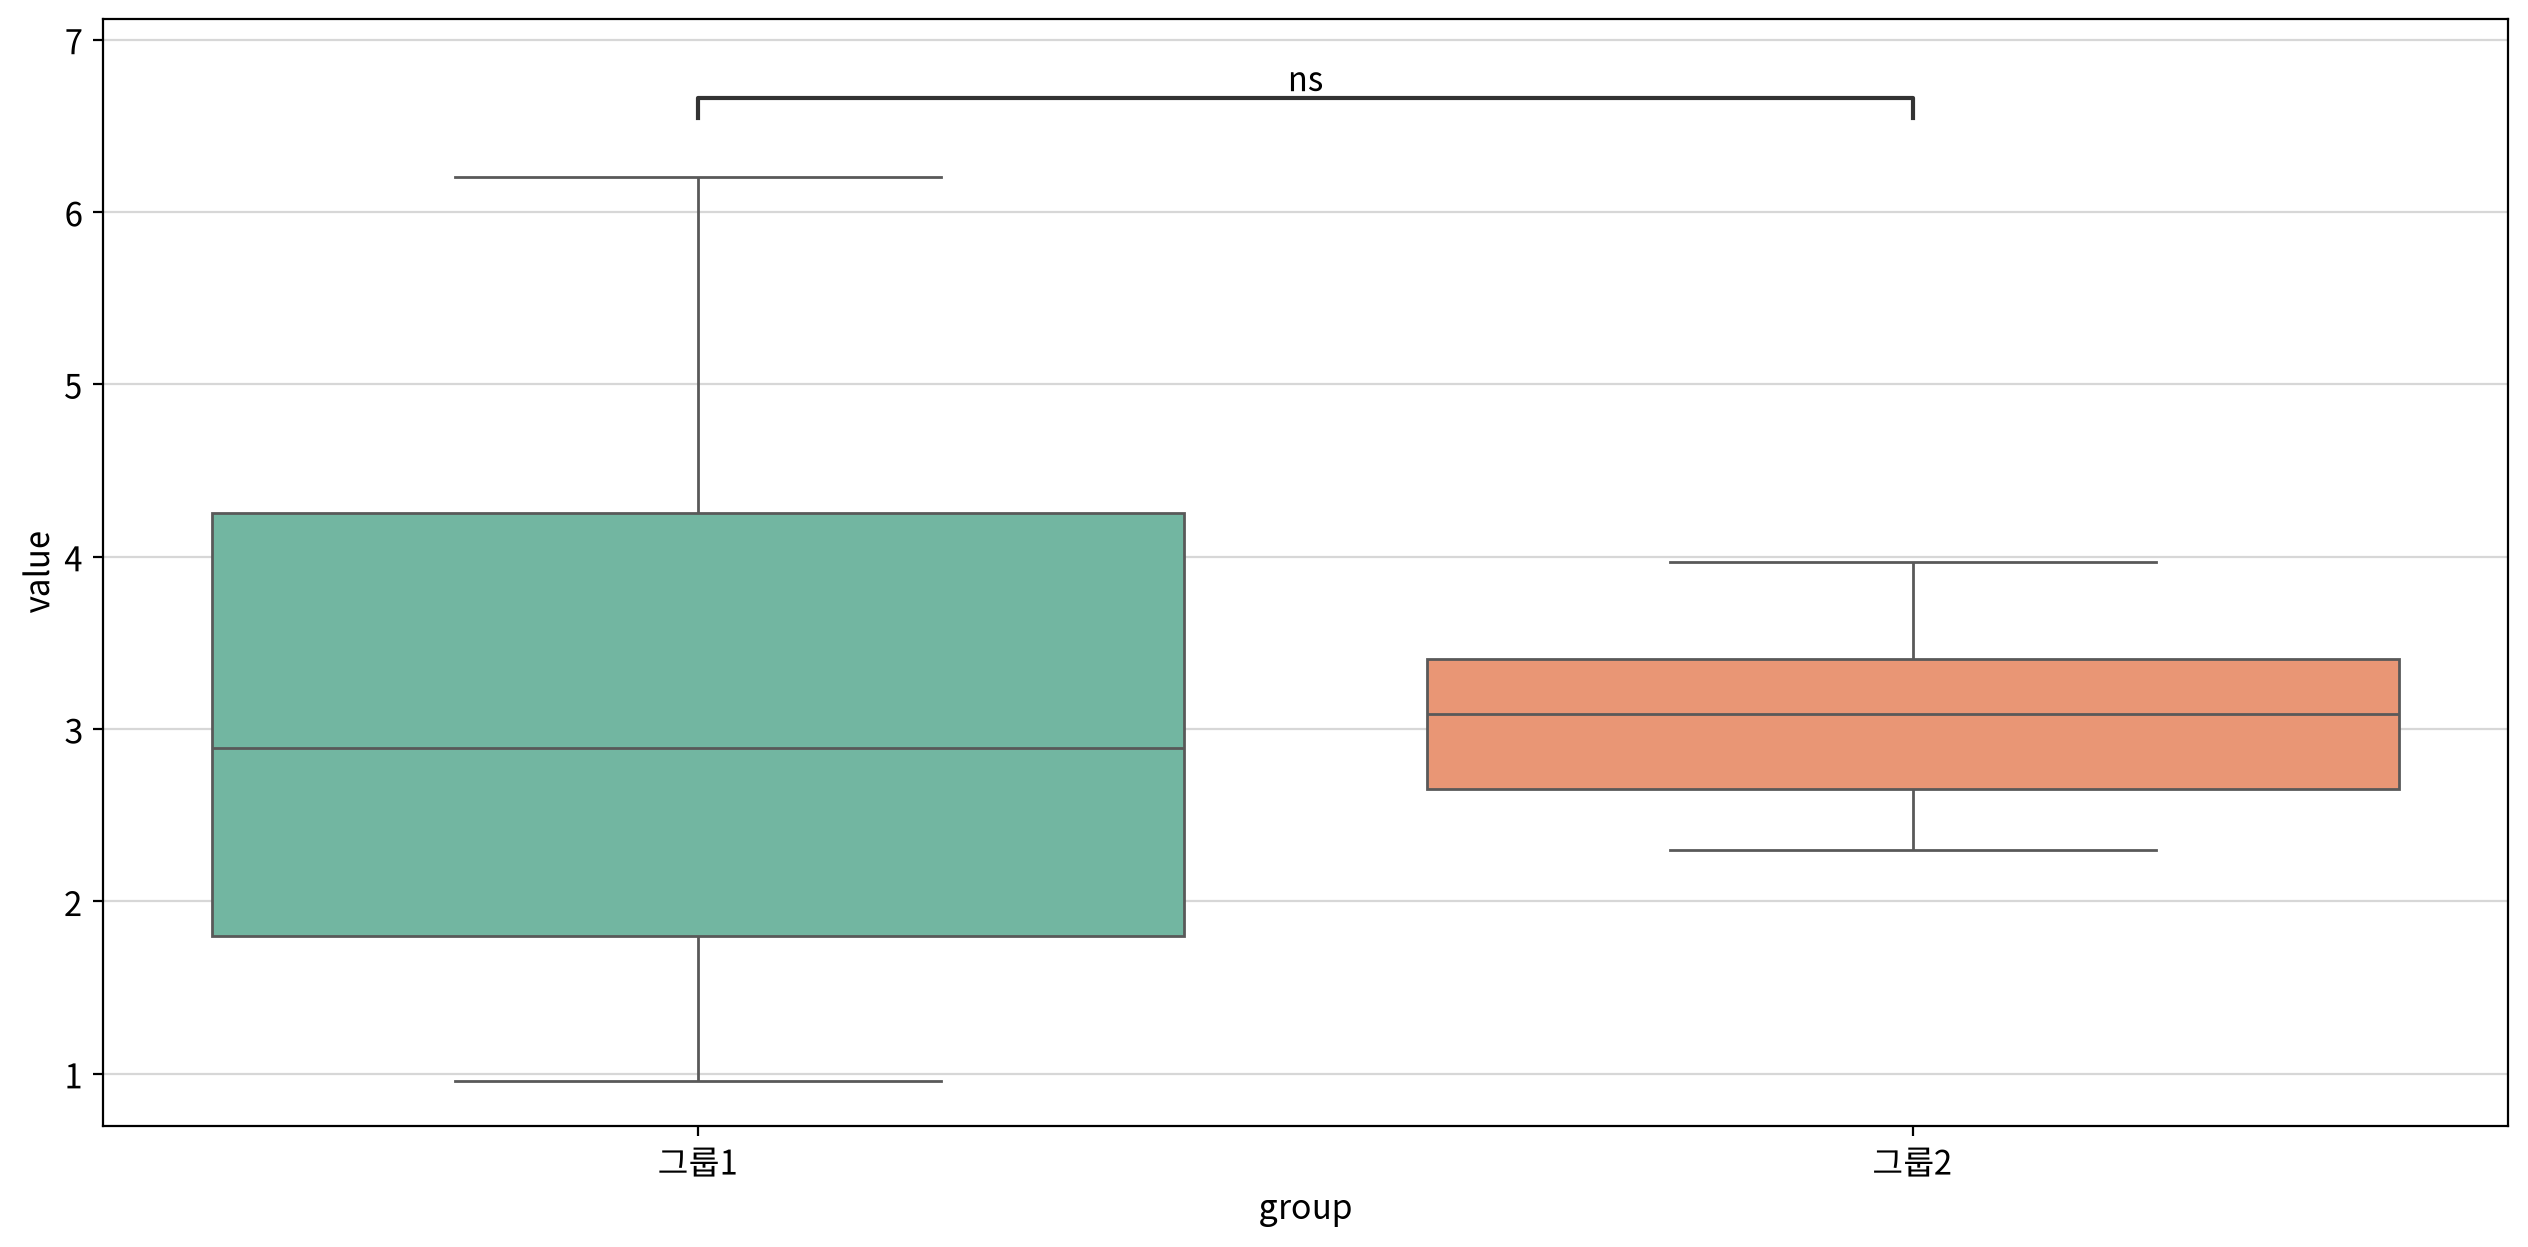

In [284]:
fig, ax = my_plot.init()
my_plot.boxplot(data=df2_melt, 
                x="group", y="value", hue="group", 
                palette="Set2", ax=ax)

# 독립표본 T검정 결과를 시각화에 추가 
annotator = Annotator(ax, 
                      data=df2_melt, 
                      x='group', 
                      y='value', 
                      pairs=[('그룹1', '그룹2')]
                      )

# 가설검정 알고리즘 종류 ( 't-test_ind', 't-test_paired', 't-test_welch', 'Mann-Whitney',
# 'Mann-Whitney-gt', 'Mann-Whitney-ls', 'Levene', 'Wilcoxon', 'Kruskal' 등을 지원)

annotator.configure(test='t-test_welch')
annotator.apply_and_annotate()

my_plot.show()

## #03. 예제(3) - 두 종류의 진통제 효과 비교 

### 1. 데이터 가져오기 

In [285]:
df3 = load_data("analgesic")
df3.head()

📚 두 종류의 진통제(약물A, 약물B)를 투여한 후 통증이 완화되기까지 걸린 시간(분)을 측정한 가상의 자료.


,group,value
0,약물A,17.300
1,약물A,12.600
2,약물A,18.600
3,약물A,28.800
4,약물A,12.000


### 2. 데이터 분포 확인 

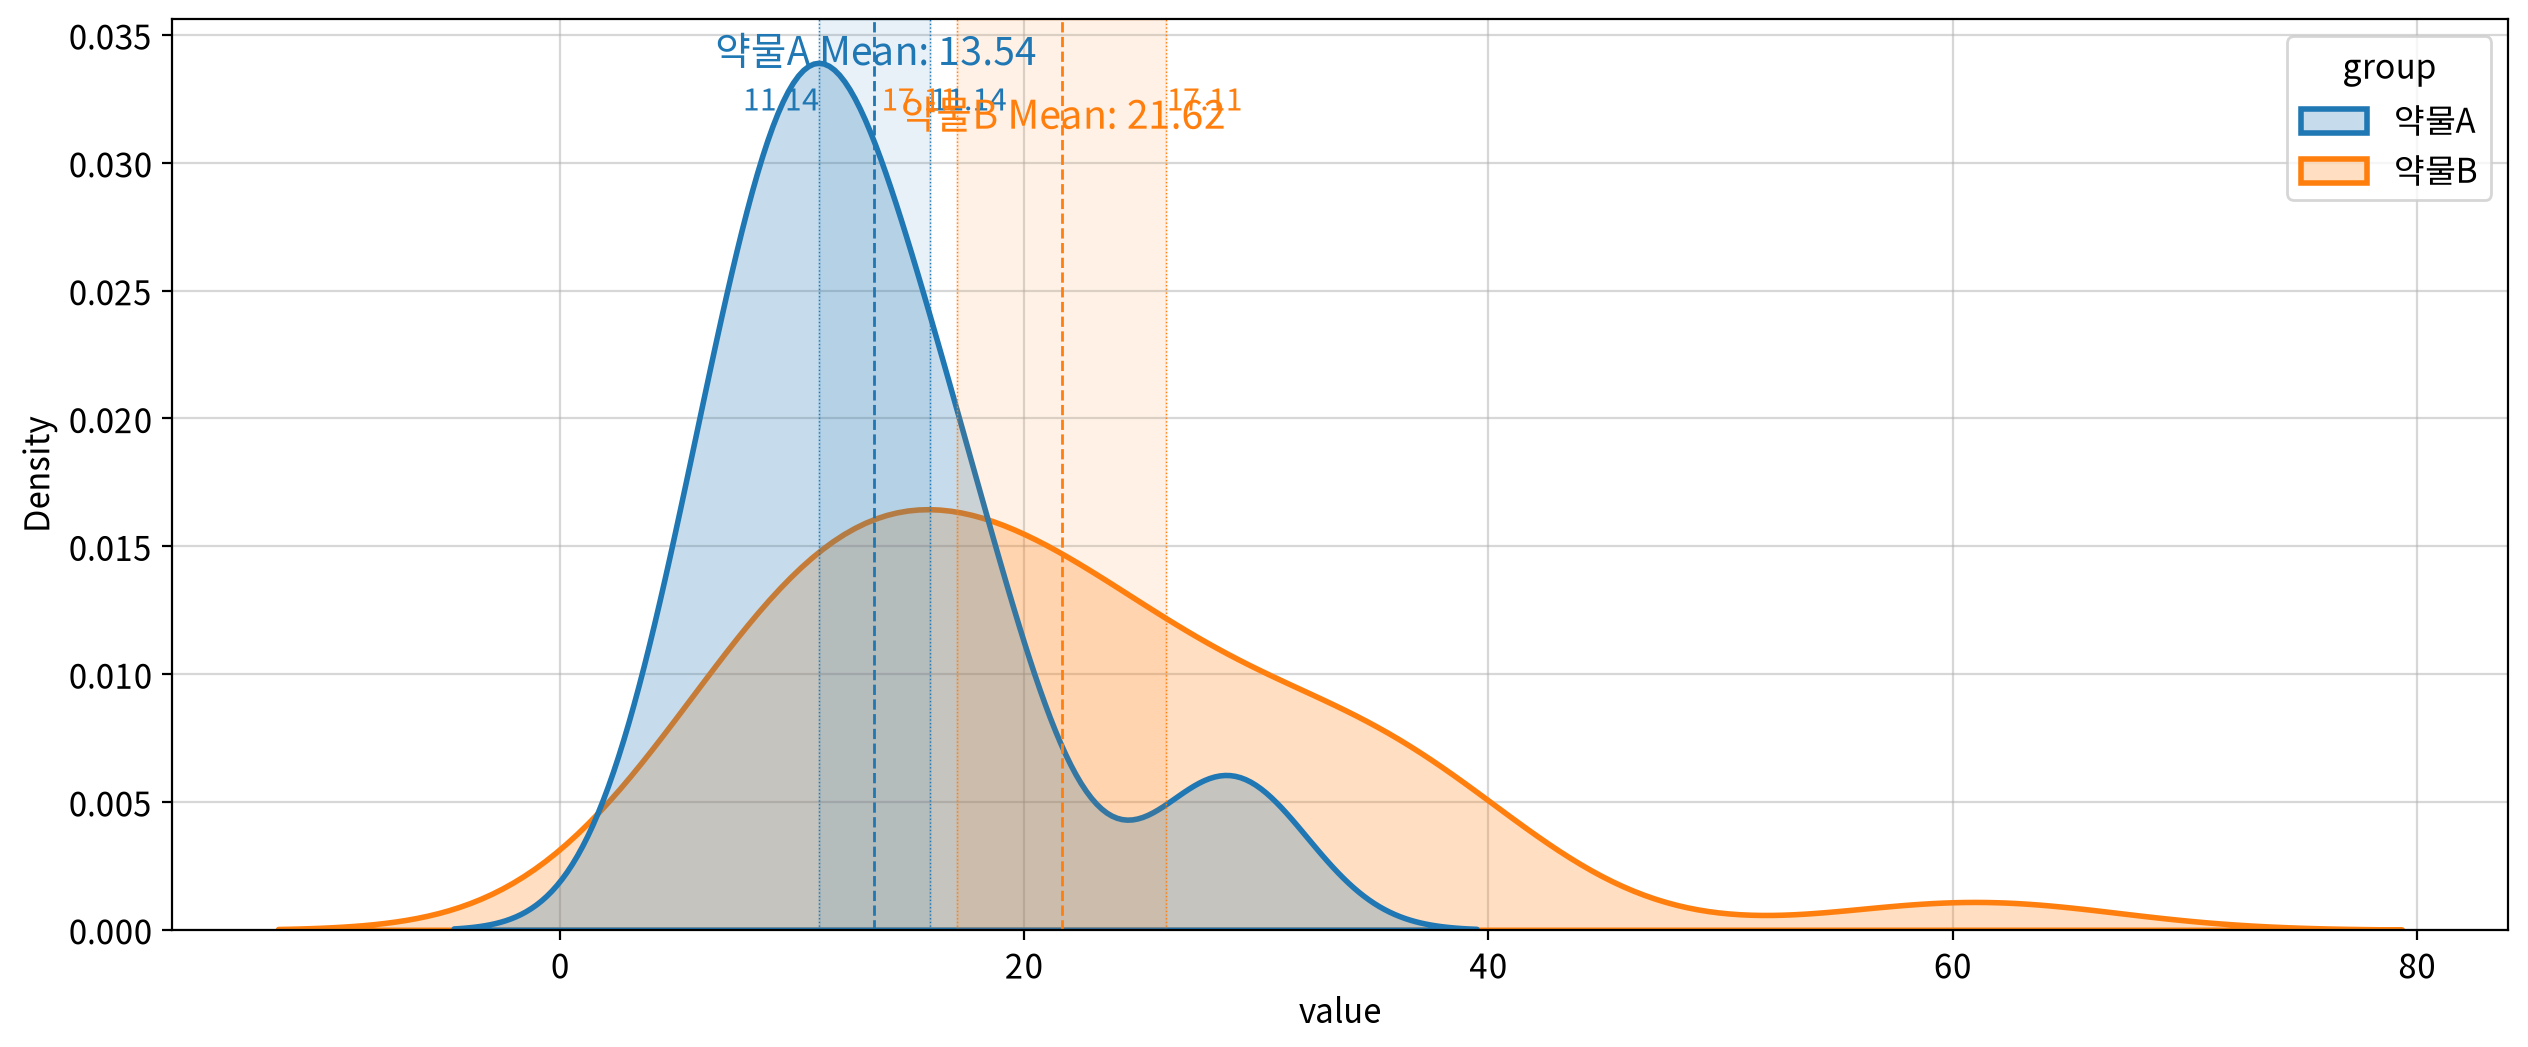

In [286]:
my_plot.kdeplot(df3, x="value", hue="group", fill=True, 
                meanline=True, clevel=0.95)

### 3. long타입을 wide 타입으로 재배치 (1) - 그룹별 일련번호 생성 

In [287]:
df3_group = df3.copy()
df3_group['idx'] = df3_group.groupby("group").cumcount()
df3_group.head()

,group,value,idx
0,약물A,17.300,0
1,약물A,12.600,1
2,약물A,18.600,2
3,약물A,28.800,3
4,약물A,12.000,4


### 4. long타입을 wide 타입으로 재배치 (2) - pivot_table 구성  

In [288]:
df3_pivot = pivot_table(df3_group, index='idx', 
                        columns='group', values='value')
df3_pivot.head()

group,약물A,약물B
idx,,
0,17.300,14.000
1,12.600,61.000
2,18.600,19.900
3,28.800,10.600
4,12.000,32.900


### 5. 가설검정의 가정 확인 

In [289]:
my_stats.test_assumptions(df3_pivot)

,test,statistic,p-value,result
field,,,,
약물A,normaltest,9.191,0.010,False
약물B,normaltest,11.884,0.003,False
Levene,equal_var,7.304,0.009,False


### 6. Mann-Whitny U 양측검정 

In [290]:
s, p = mannwhitneyu(df3_pivot['약물A'], df3_pivot['약물B'], 
                    alternative='two-sided')
print(f"statistic: {s:.4f}, p-value: {p:.4f}")

statistic: 249.0000, p-value: 0.0030


### 6. Mann-Whitny U 좌측 단측 검정  

In [291]:
s, p = mannwhitneyu(df3_pivot['약물A'], df3_pivot['약물B'],
                     alternative='less')
print(f"statistic: {s:.4f}, p-value: {p:.4f}")

statistic: 249.0000, p-value: 0.0015


### 6. Mann-Whitny U 우측 단측 검정  

In [292]:
s, p = mannwhitneyu(df3_pivot['약물A'], df3_pivot['약물B'],
                     alternative='greater')
print(f"statistic: {s:.4f}, p-value: {p:.4f}")

statistic: 249.0000, p-value: 0.9986


### 7. 가설검정 시각화 

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

약물A vs. 약물B: Mann-Whitney-Wilcoxon test two-sided, P_val:3.031e-03 U_stat=2.490e+02


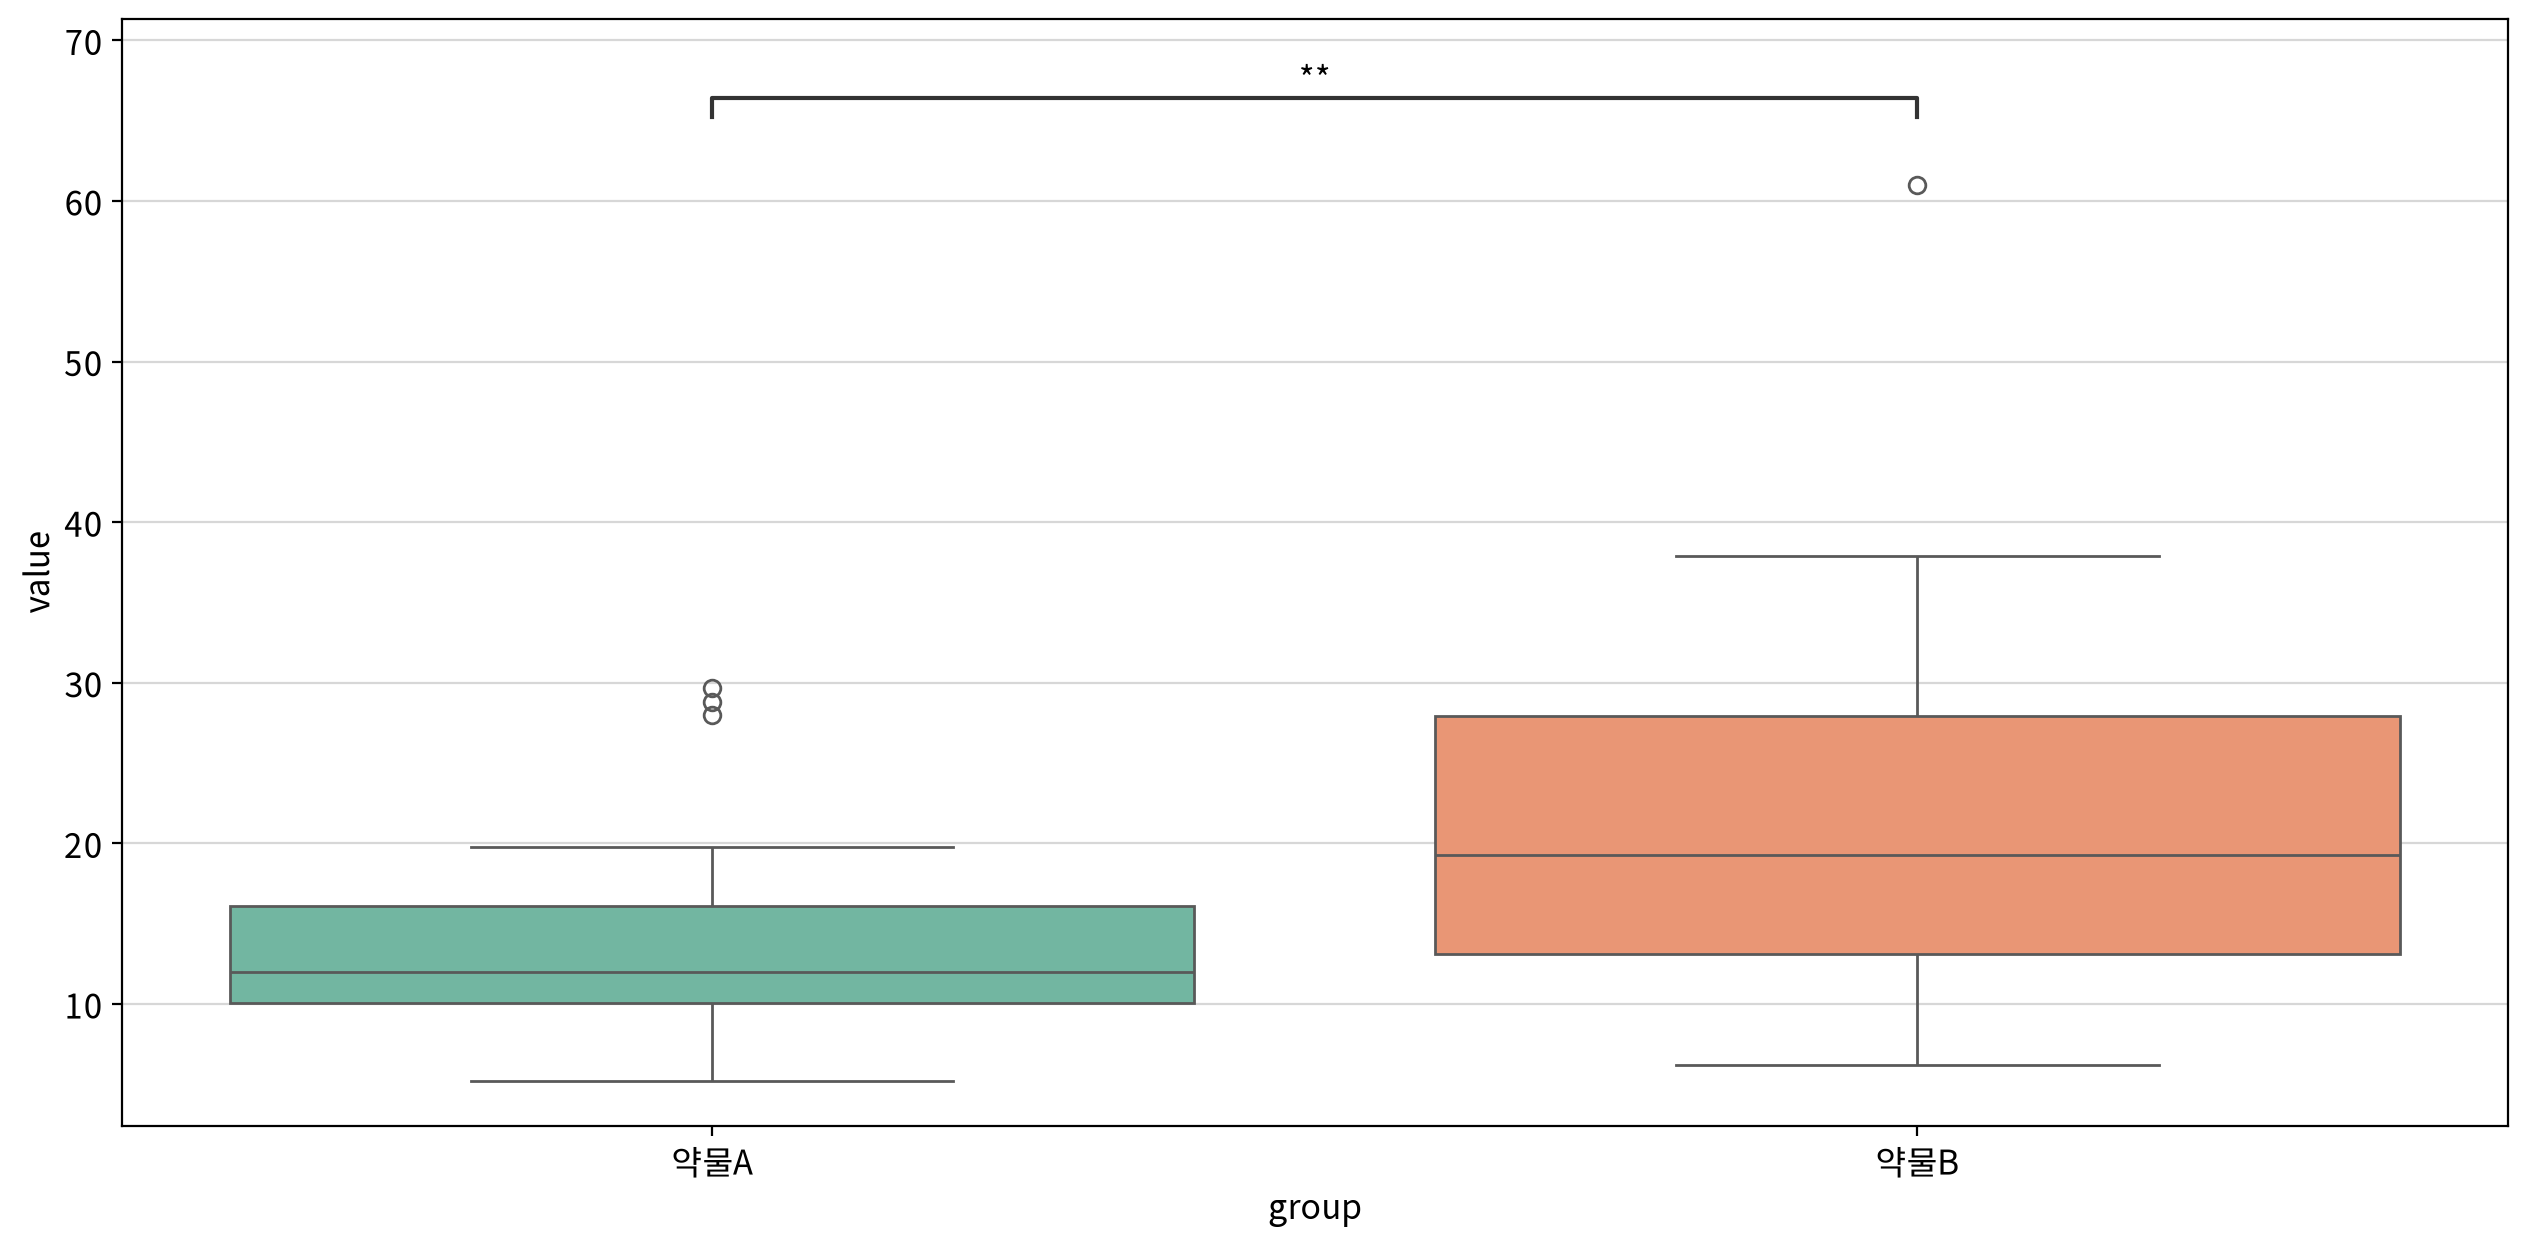

In [293]:
fig, ax = my_plot.init()
my_plot.boxplot(data = df3, 
                x="group", y="value", hue="group", 
                palette="Set2", ax=ax)

# 독립표본 T검정 결과를 시각화에 추가 
annotator = Annotator(ax, 
                      data=df3, 
                      x='group', 
                      y='value', 
                      pairs=[('약물A', '약물B')]
                      )

# 가설검정 알고리즘 종류 
# -> 양측 검정 : Mann-Whitney 
#    좌측 단측 검정 : Mann-Whitney-lt
#    우측 단측 검정 : Mann-whitney-lt
annotator.configure(test='Mann-Whitney')
annotator.apply_and_annotate()

my_plot.show()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

약물A vs. 약물B: Mann-Whitney-Wilcoxon test two-sided, P_val:3.031e-03 U_stat=2.490e+02


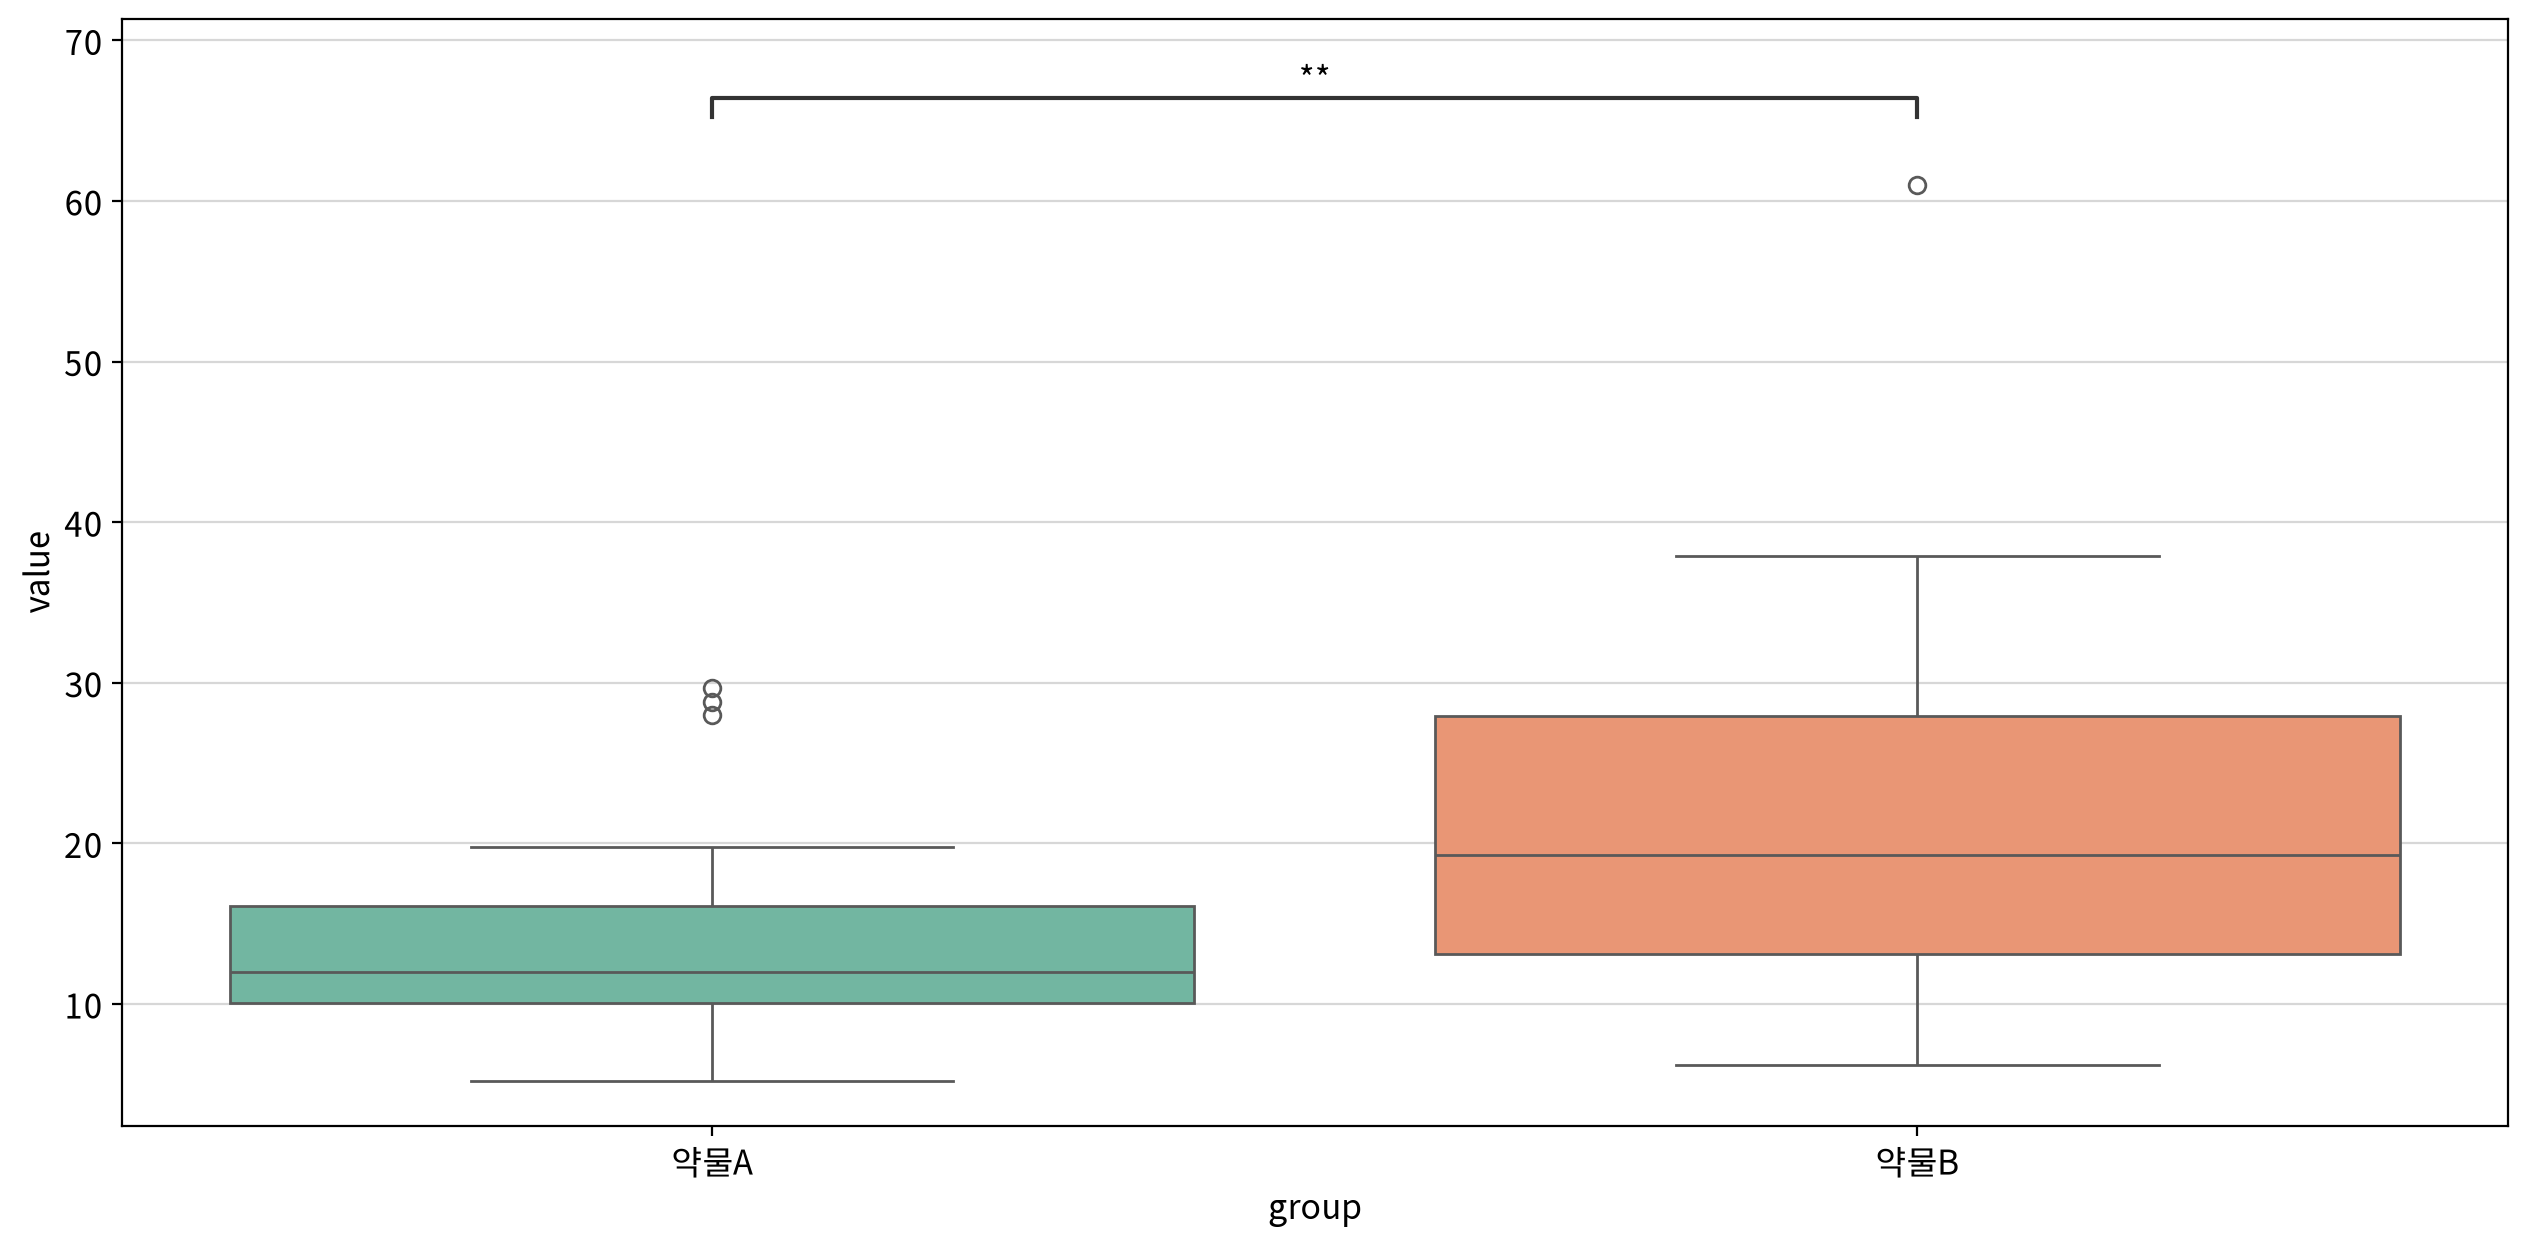

In [294]:
fig, ax = my_plot.init()
my_plot.boxplot(data = df3_group, 
                x="group", y="value", hue="group", 
                palette="Set2", ax=ax)

# 독립표본 T검정 결과를 시각화에 추가 
annotator = Annotator(ax, 
                      data=df3_group, 
                      x='group', 
                      y='value', 
                      pairs=[('약물A', '약물B')]
                      )

# 가설검정 알고리즘 종류 
# -> 양측 검정 : Mann-Whitney 
#    좌측 단측 검정 : Mann-Whitney-lt
#    우측 단측 검정 : Mann-whitney-lt
annotator.configure(test='Mann-Whitney')
annotator.apply_and_annotate()

my_plot.show()

In [295]:
# 가설검정 알고리즘 종류 
# -> 양측 검정 : Mann-Whitney 
#    좌측 단측 검정 : Mann-Whitney-lt
#    우측 단측 검정 : Mann-whitney-lt
annotator.configure(test='Mann-Whitney')
annotator.apply_and_annotate()

my_plot.show()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

약물A vs. 약물B: Mann-Whitney-Wilcoxon test two-sided, P_val:3.031e-03 U_stat=2.490e+02


<Figure size 1280x960 with 0 Axes>

In [296]:
print(df3_pivot.columns)

Index(['약물A', '약물B'], dtype='str', name='group')


## #05. 모듈화 기능 확인 

### 1. 지혈제 효과 비교 

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

B vs. G: t-test independent samples, P_val:3.862e-04 t=-4.350e+00


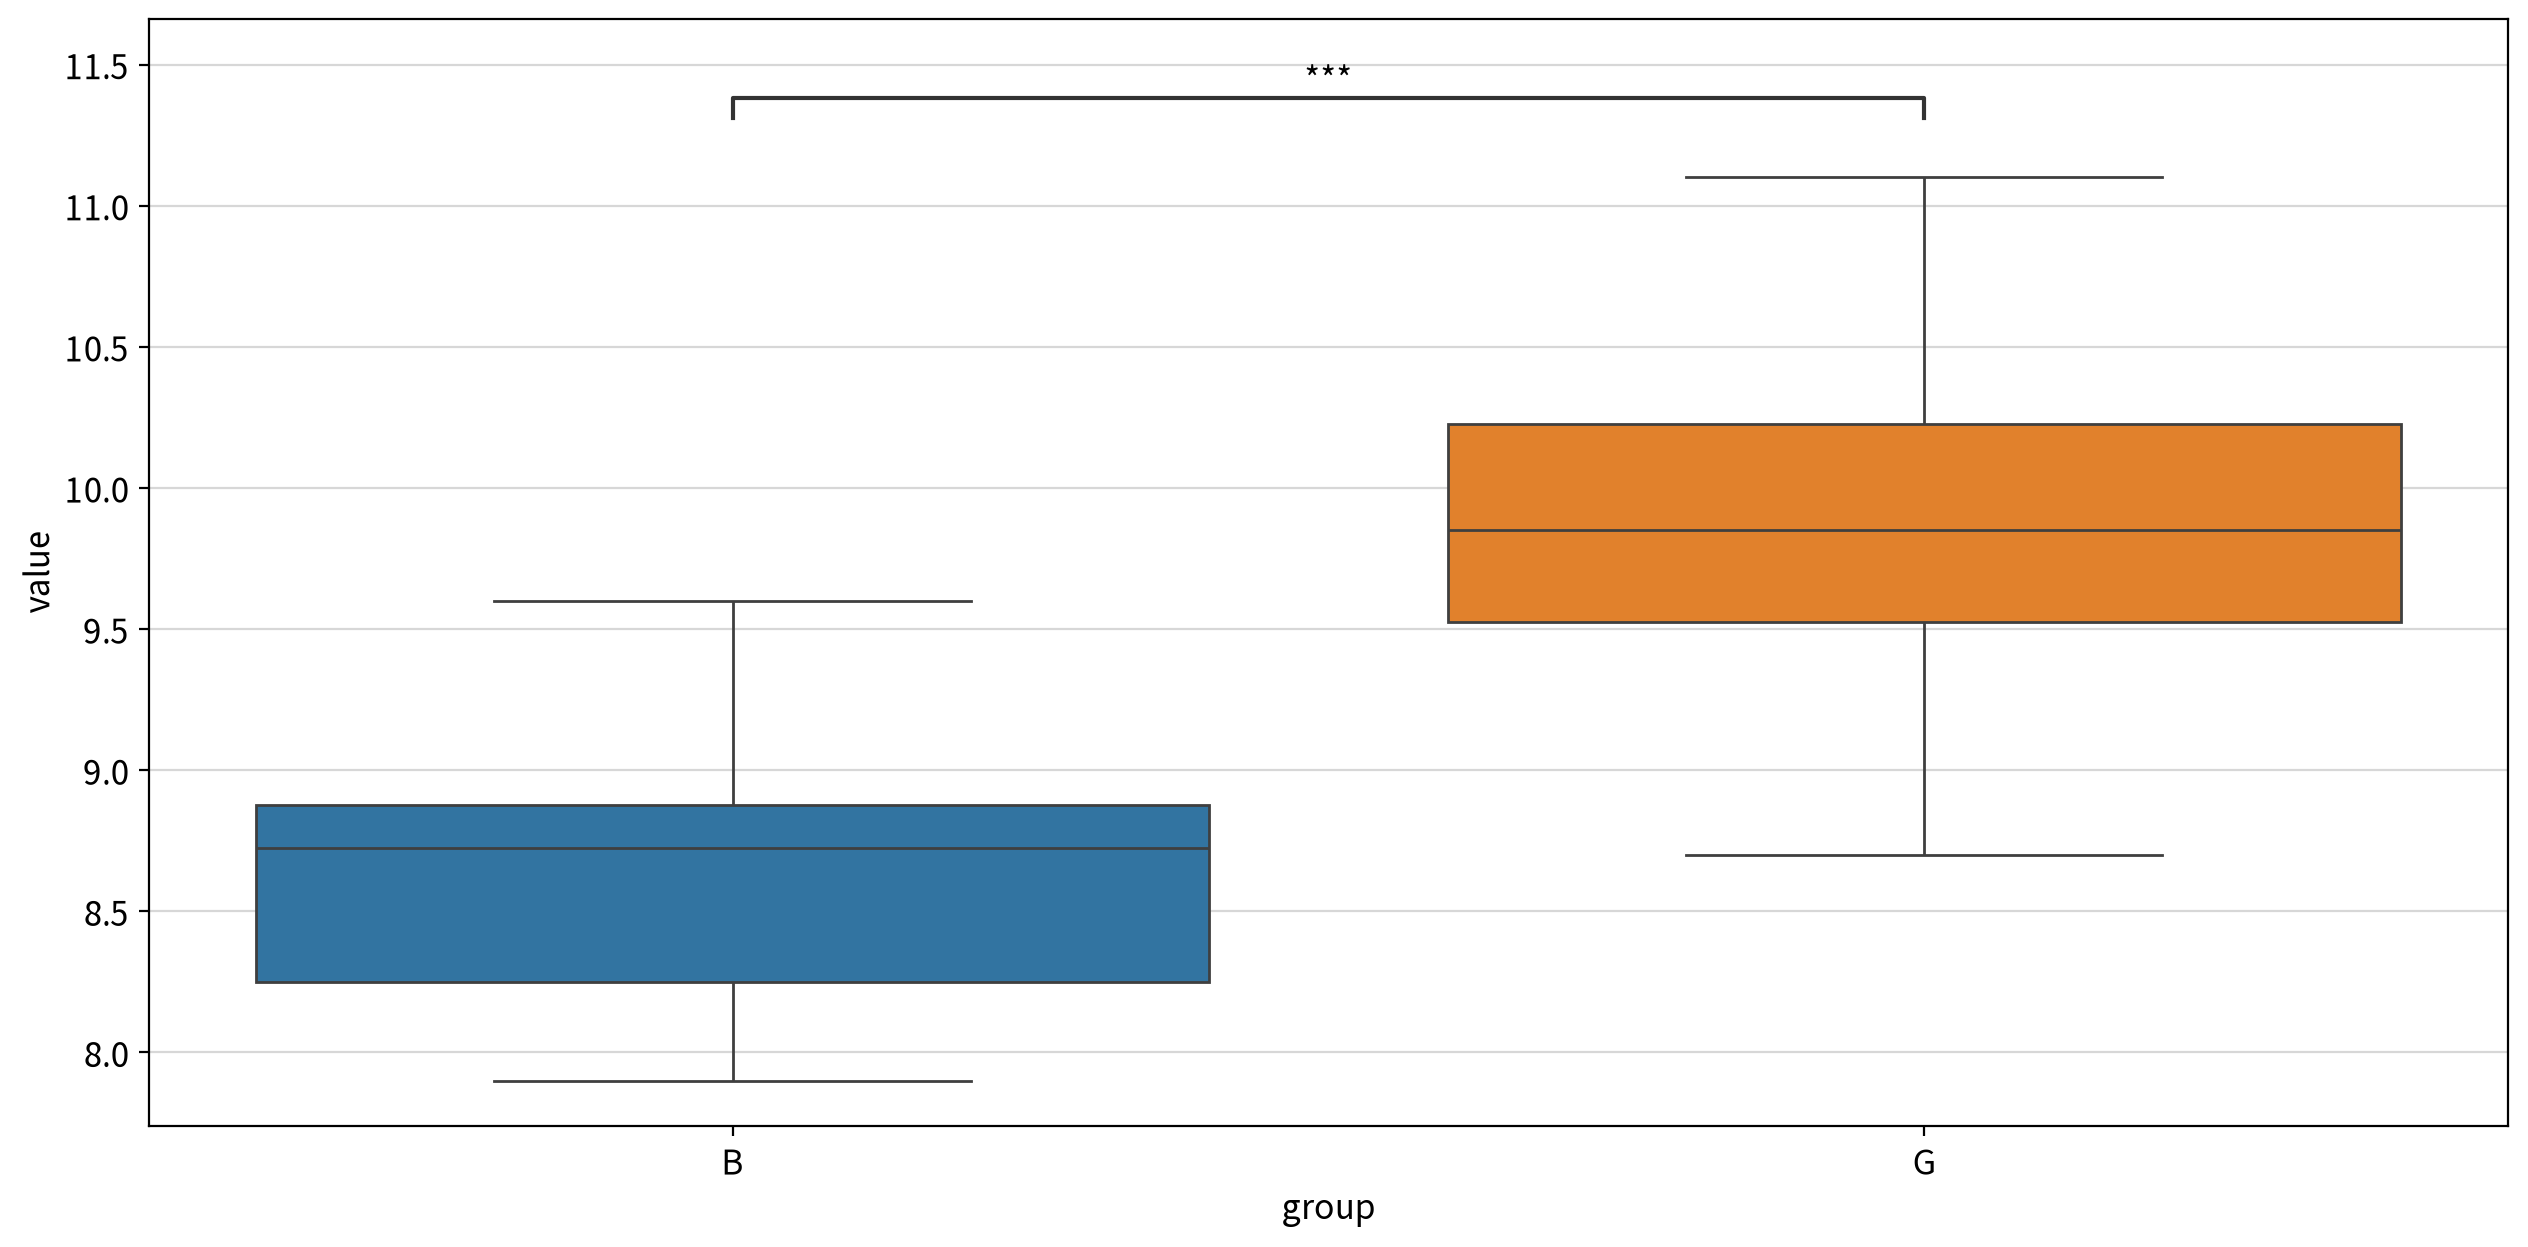

statistic  p-value  significant   result
test           alternative                                          
Student t-test two-sided       -4.350    0.000         True  B =/= G
               less            -4.350    0.000         True    B < G
               greater         -4.350    1.000        False   B <= G

In [297]:
my_stats.test_independent(df1, "B", "G")

### 2. 인공심장 효과 측정 

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

그룹1 vs. 그룹2: Welch's t-test independent samples, P_val:8.742e-01 t=1.633e-01


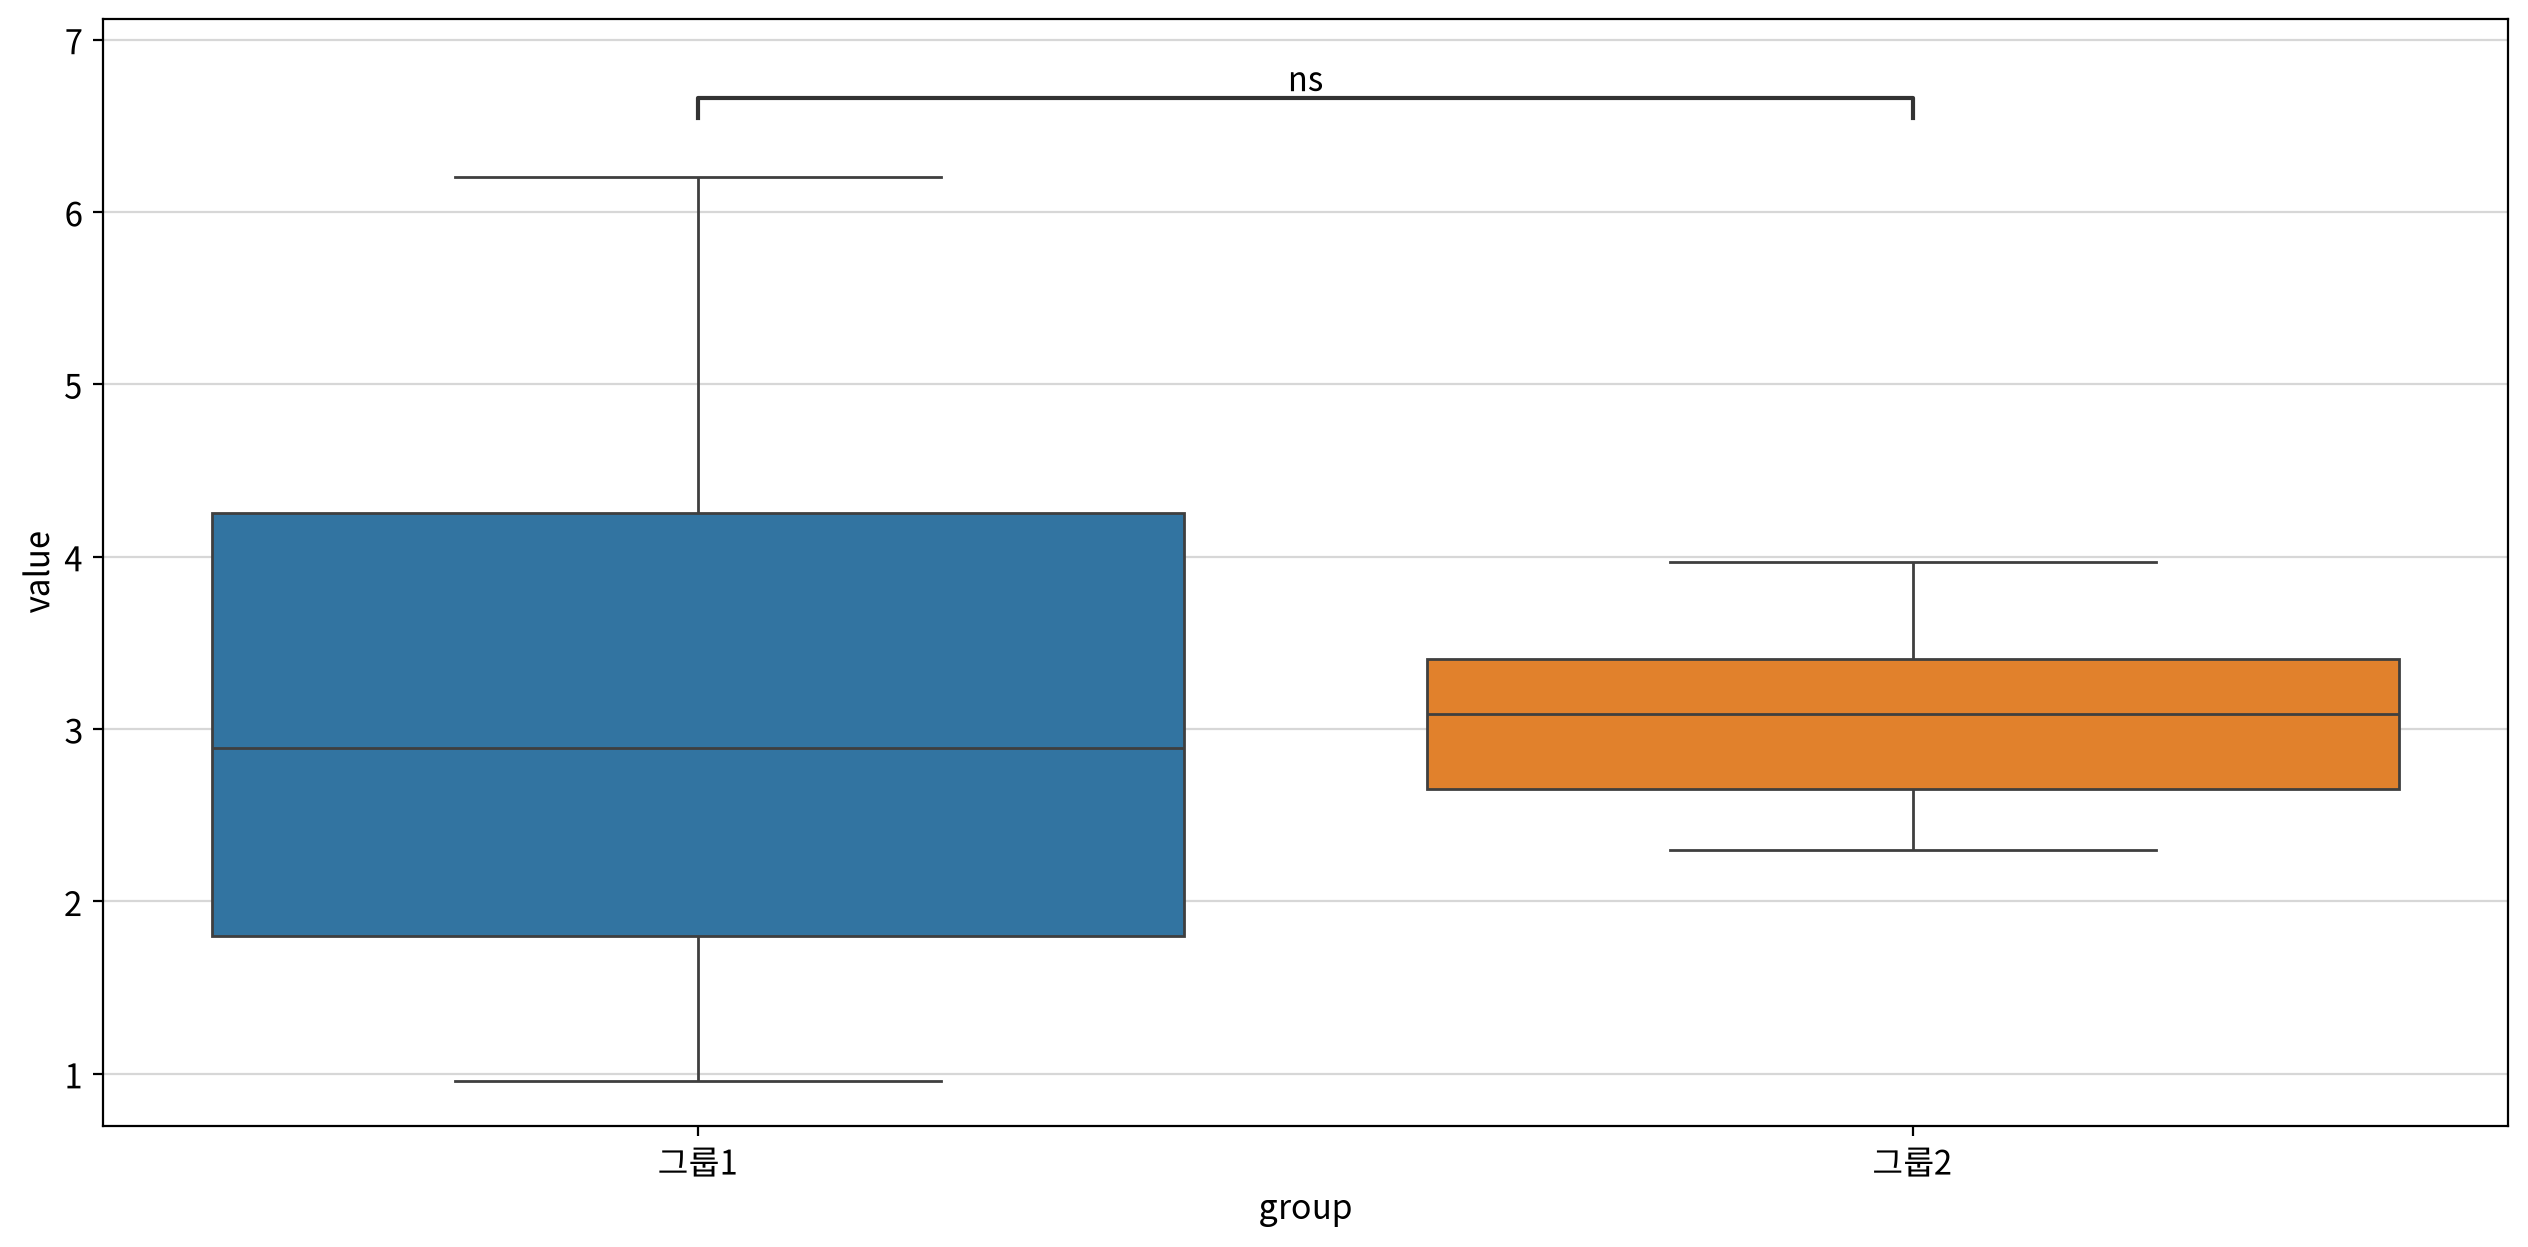

statistic  p-value  significant      result
test         alternative                                             
Welch t-test two-sided        0.163    0.874        False   그룹1 = 그룹2
             less             0.163    0.563        False  그룹1 >= 그룹2
             greater          0.163    0.437        False  그룹1 <= 그룹2

In [298]:
my_stats.test_independent(df2, "그룹1", "그룹2")

### 3. 두 종류의 진통제 효과 비교 

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

약물A vs. 약물B: Mann-Whitney-Wilcoxon test two-sided, P_val:3.031e-03 U_stat=2.490e+02


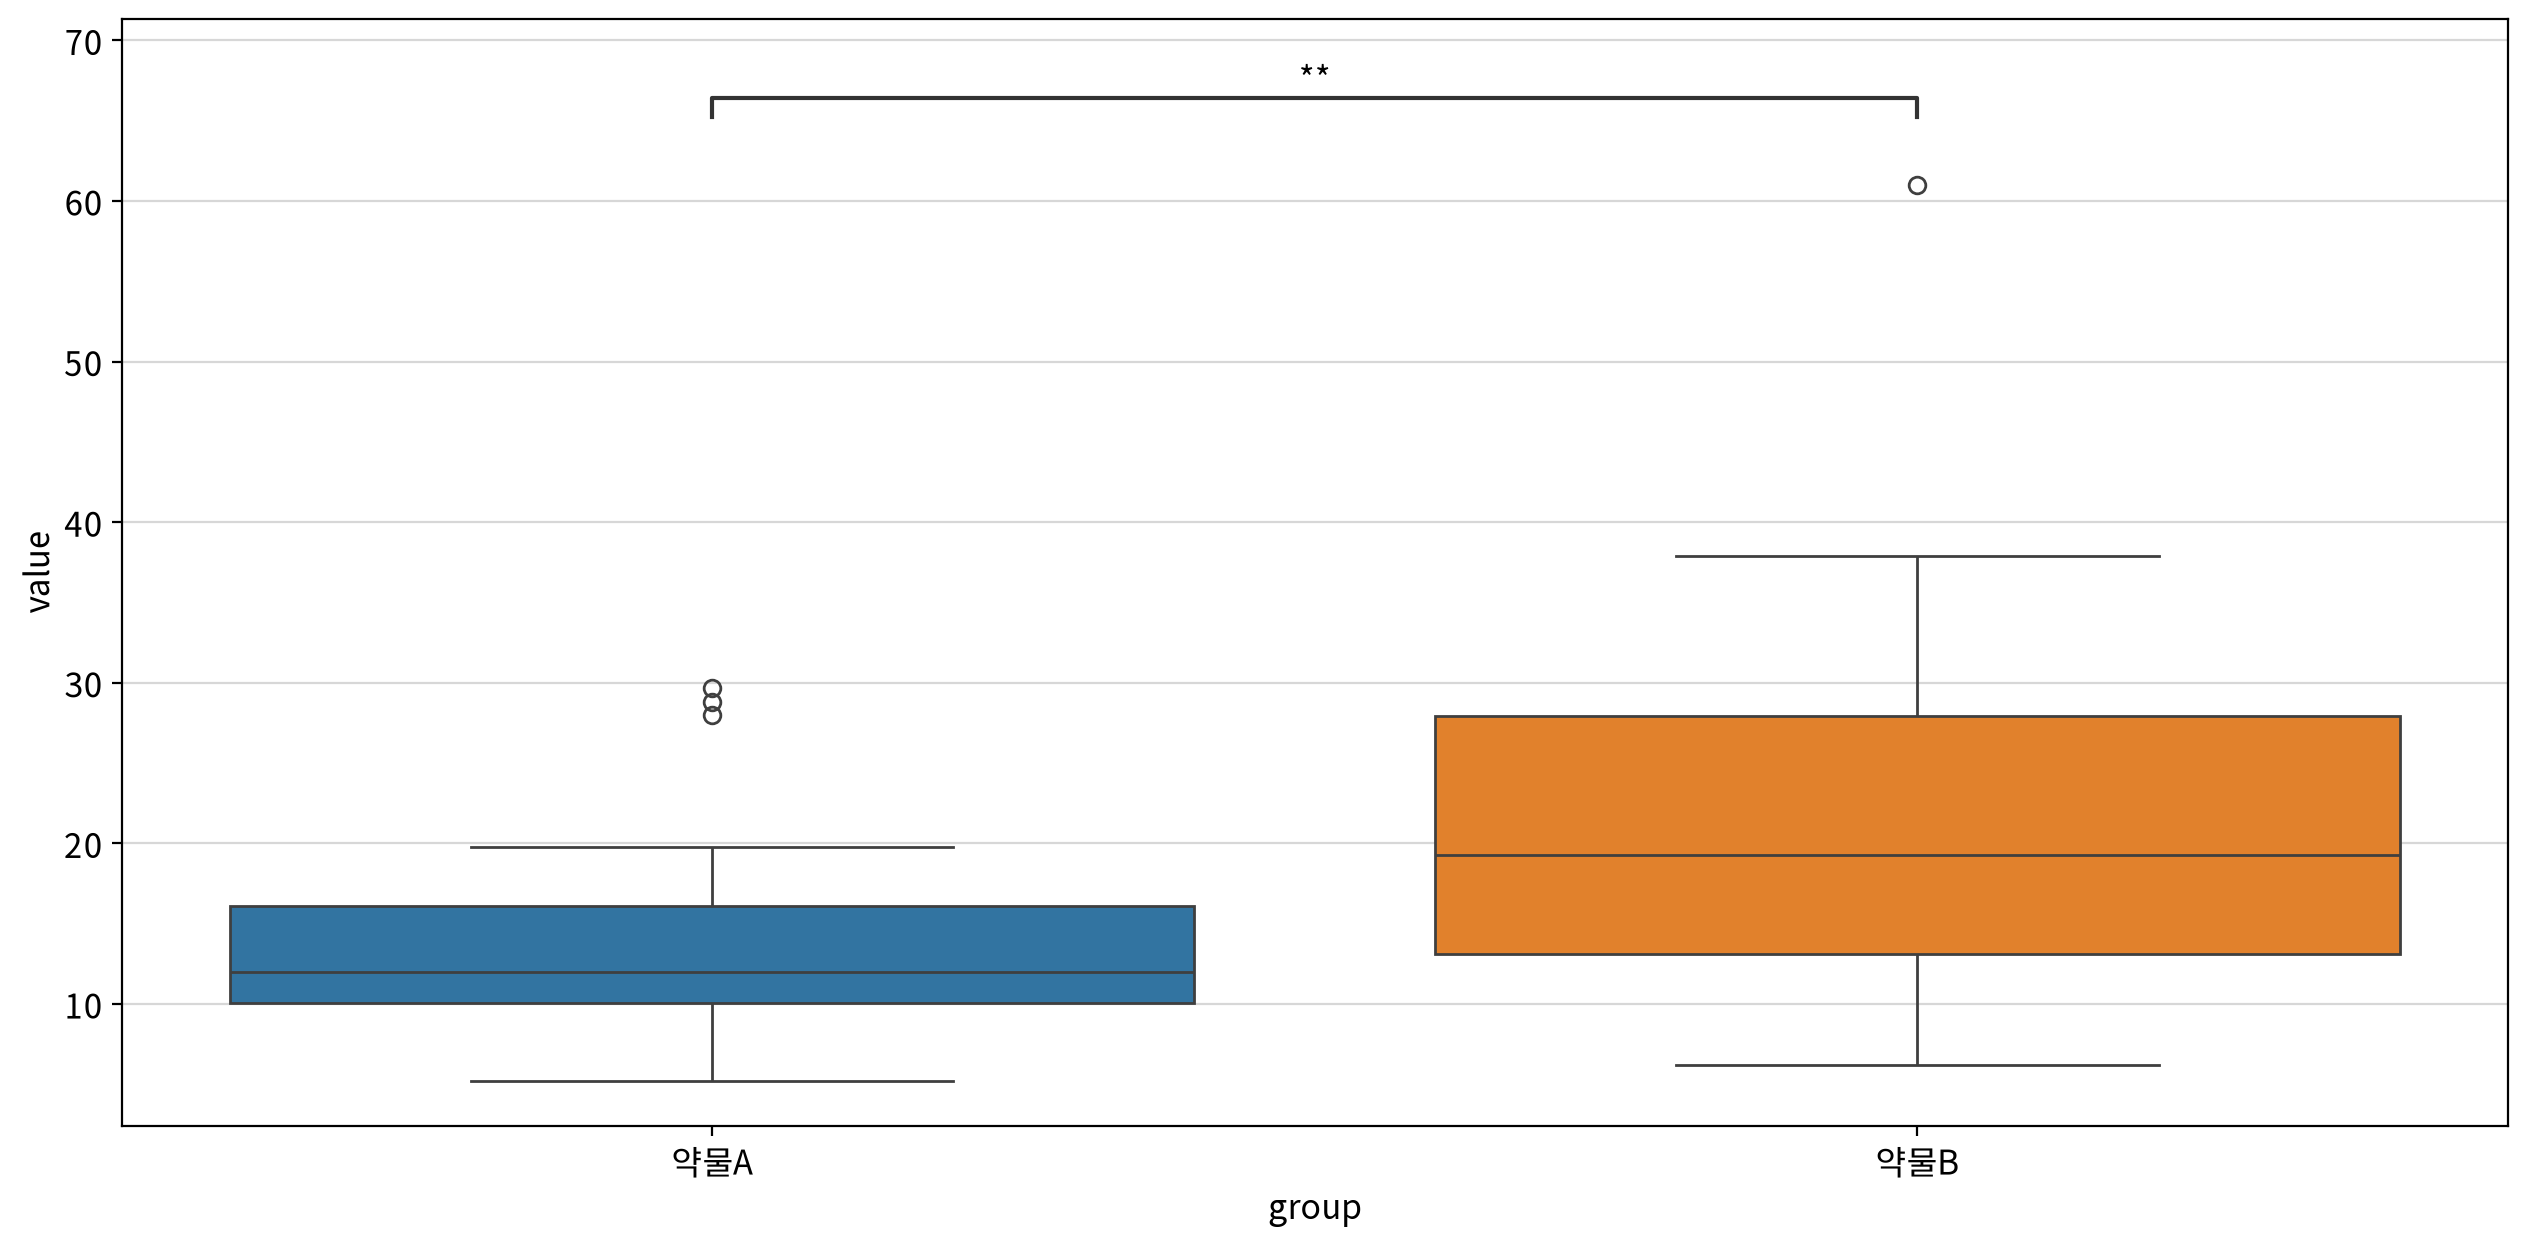

statistic  p-value  significant       result
test                alternative                                              
Mann-Whitney U test two-sided      249.000    0.003         True  약물A =/= 약물B
                    less           249.000    0.002         True    약물A < 약물B
                    greater        249.000    0.999        False   약물A <= 약물B

In [299]:
my_stats.test_independent(df3_pivot, "약물A", "약물B")

## #01. 연습문제 - 독립표본 T검정 연습문제 

In [300]:
from jussam import load_data
from helpers import *

In [301]:
df = load_data('material')
df.head()

📚 어떤 화학 약품에 사용되는 서로 다른 상표의 주성분 A 함량표 (출처: 방송통신대학교 통계학개론)


,상표1,상표2
0,80.400,81.800
1,78.200,82.700
2,80.100,80.700
3,77.100,84.000
4,79.600,79.000


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

상표1 vs. 상표2: t-test independent samples, P_val:1.421e-01 t=-1.528e+00


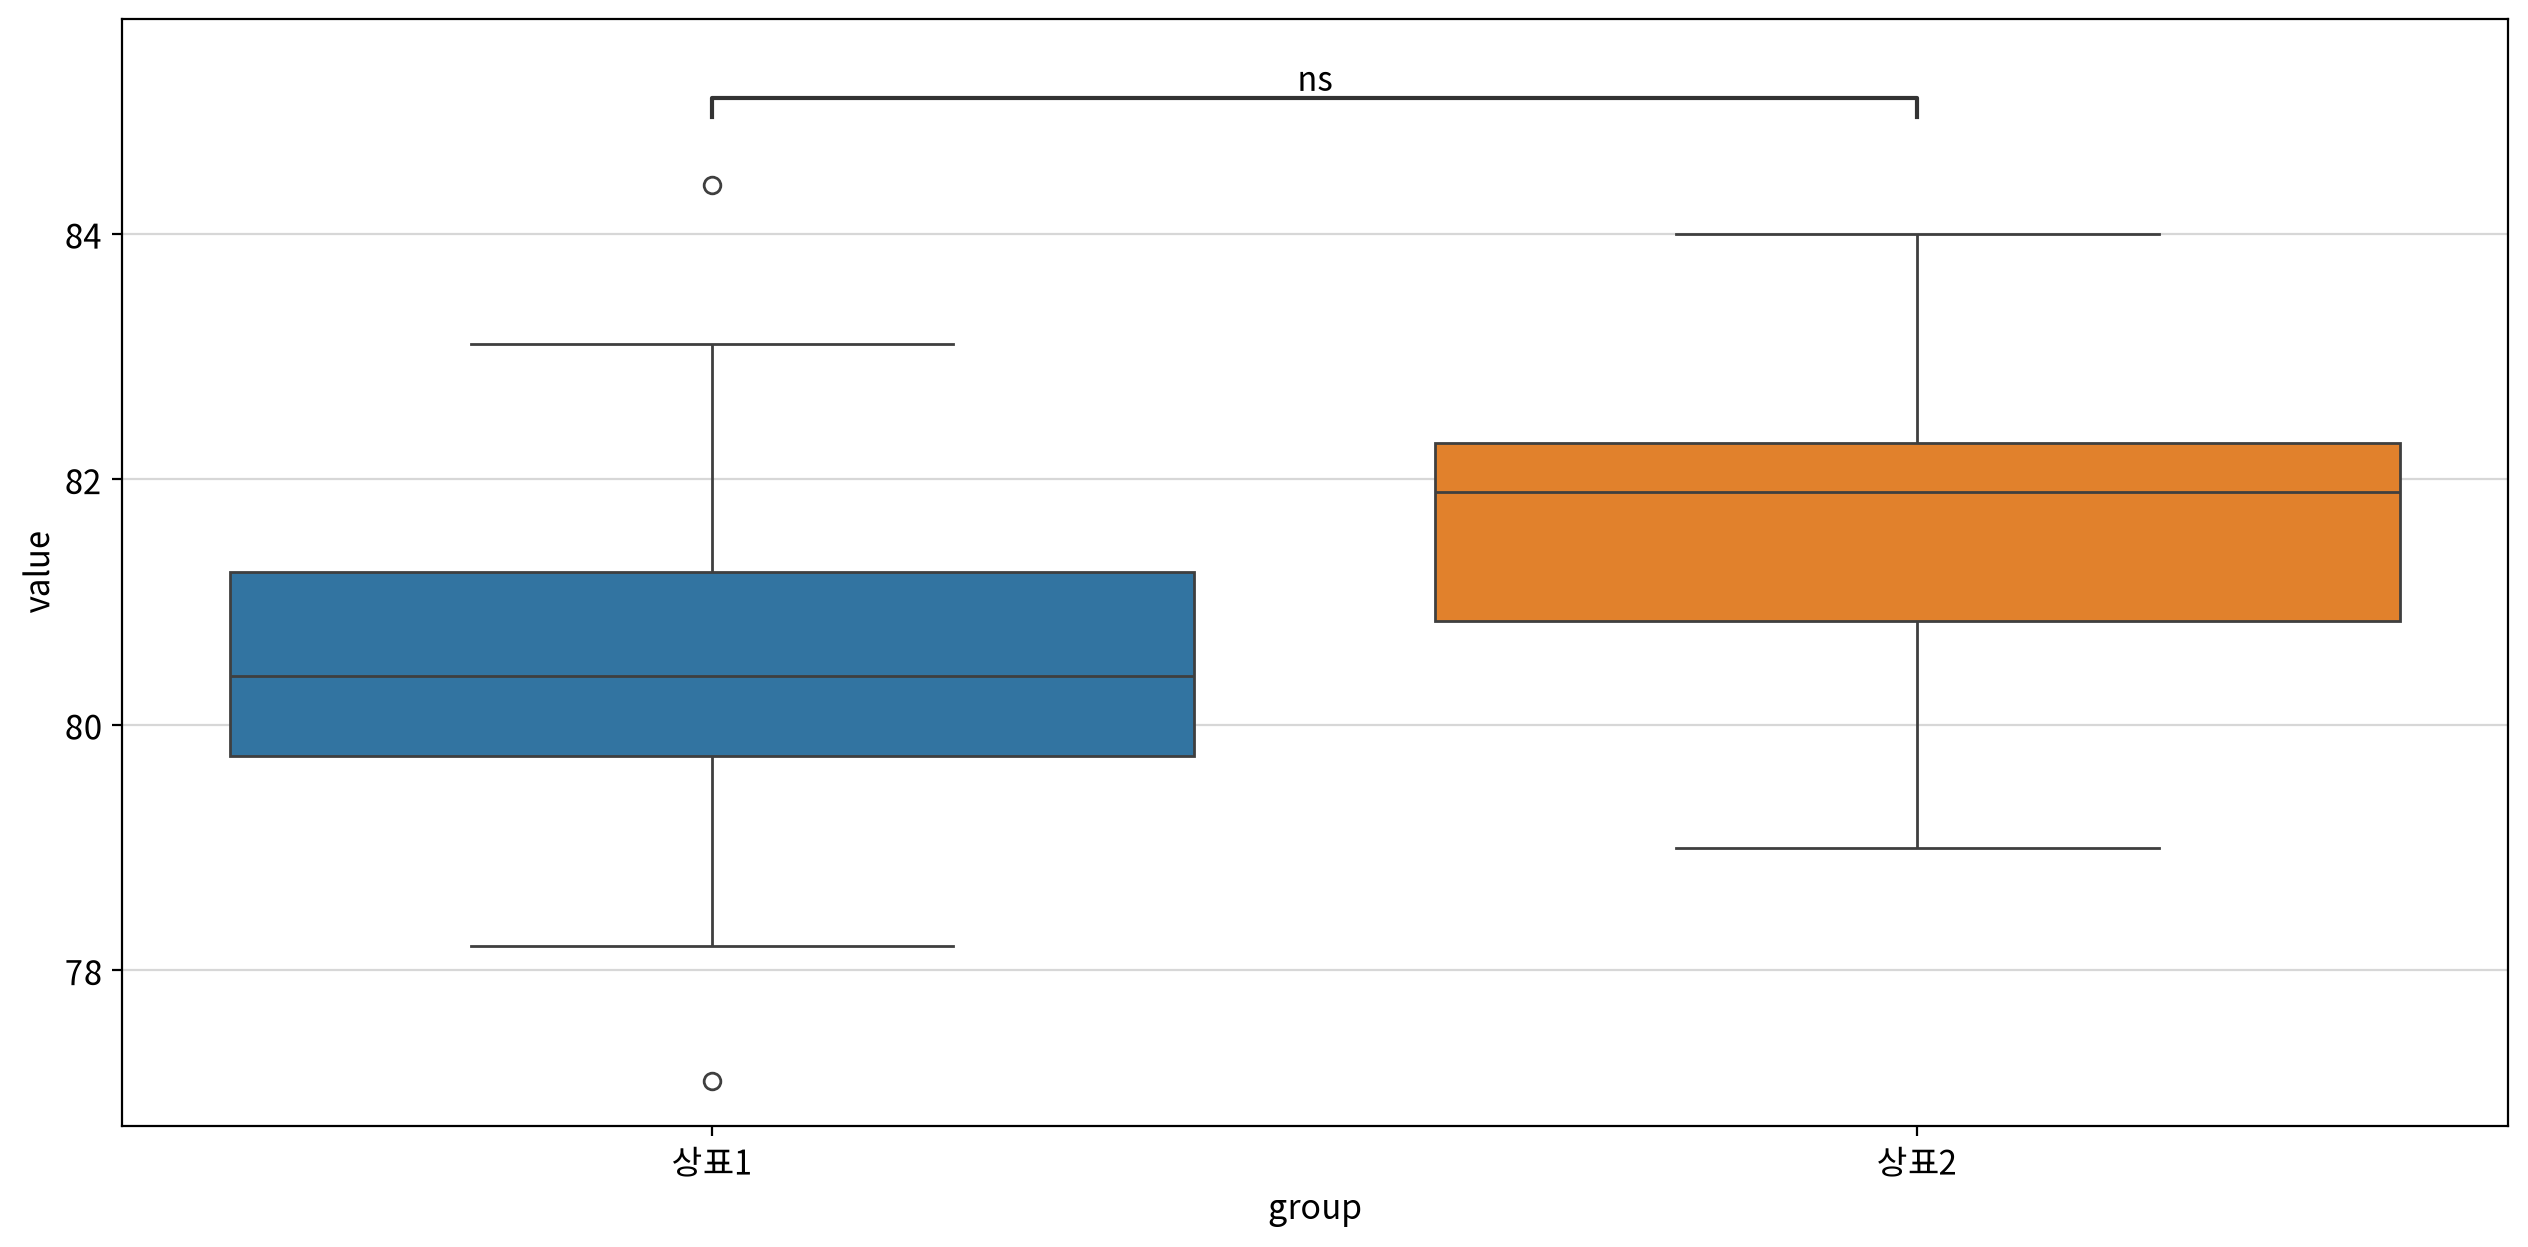

statistic  p-value  significant      result
test           alternative                                             
Student t-test two-sided       -1.528    0.142        False   상표1 = 상표2
               less            -1.528    0.071        False  상표1 >= 상표2
               greater         -1.528    0.929        False  상표1 <= 상표2

In [302]:
my_stats.test_independent(df, "상표1", "상표2")

## #02. 연습문제 

In [303]:
df = load_data('adult_height')
df.head()

📚 성인 30명의 성별(sex), 신장(height) 데이터 (출처: 방송통신대학교 바이오통계학)


,sex,height
0,F,161
1,F,160
2,F,164
3,F,172
4,F,157


In [304]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   sex     30 non-null     str  
 1   height  30 non-null     int64
dtypes: int64(1), str(1)
memory usage: 642.0 bytes


In [305]:
df.isna().sum()

sex       0
height    0
dtype: int64

In [306]:
df['idx'] = df.groupby('sex').cumcount()
df1

,B,G
0,8.800,9.900
1,8.900,10.000
2,8.400,9.000
3,7.900,11.100
4,8.200,9.800
5,8.700,9.600
6,7.900,10.300
7,9.100,8.700
8,9.600,10.400
9,8.750,9.500


In [307]:
# count()랑 헷갈리는 게 자연스러운 게, 이름은 비슷한데 완전히 다른 걸 계산하거든:

# count(): 그룹별로 결측치 아닌 값이 몇 개있는지 세는 집계 함수. 결과는 그룹 수만큼의 행으로 축약됨.

# python  df.groupby('sex').count()
#   # F    30
#   # M    28

# cumcount() (cumulative count): 각 그룹 안에서 0부터 순서대로 번호를 매기는 함수. 집계가 아니라 원본 행 개수 그대로 유지되면서 각 행에 "이 그룹 내에서 몇 번째인지"를 붙여줌.

# python  df.groupby('sex').cumcount()
#   # 0(F그룹 첫번째): 0
#   # 1(F그룹 두번째): 1
#   # 2(F그룹 세번째): 2
#   # ...
#   # (M그룹 시작하면 다시 0부터)
# 즉 count()는 "그룹당 총 개수는?"에 답하는 거고, cumcount()는 "이 행이 자기 그룹 안에서 몇 번째 행인가?"에 답하는 거야. cum-(cumulative, 누적)이라는 접두어가 붙은 이유도 그거고 — cumsum()(누적합), cumprod()(누적곱)처럼 각 행마다 그 시점까지의 누적 결과를 매기는 계열의 함수야.
# 이게 왜 필요했냐면, pivot_table로 wide 변환할 때 index로 쓸 "그룹 내에서 고유한 값"이 없으면 만들어줘야 하는데, cumcount()가 딱 그 역할(그룹별 순번 생성)을 해주는 거였어 — 바로 직전 질문에서 나온 "index가 겹치면 집계돼버린다"는 문제의 해결책으로 쓰인 거지.

In [308]:
df2 = pivot_table(df,
            index= 'idx',
            columns='sex',
            values='height')
df2.head()

sex,F,M
idx,,
0,161.000,166.000
1,160.000,157.000
2,164.000,171.000
3,172.000,174.000
4,157.000,170.000


In [309]:
# name='sex'가 붙어있는 게 보이지? 이게 눈에 보이는 형태로는 데이터프레임 출력할 때 컬럼 헤더 위에 sex라는 라벨이 한 줄 더 표시되는 걸로 나타나:
# sex    F    M
# idx
# 0    161  175
# 1    160  180
# df2.columns.name = None을 하면 이 라벨을 지워서 깔끔하게 만드는 거야:
#      F    M
# idx
# 0  161  175
# 1  160  180
# 왜 굳이 지우냐면:

# 미관상 깔끔함 — 딱히 필요 없는 메타정보라서 보고서/시각화에 넣을 때 지저분해 보임
# 후속 코드 안정성 — 나중에 이 데이터프레임을 다른 함수에 넘기거나 컬럼을 다룰 때, columns.name이 남아있으면 간혹 reset_index()나 melt() 같은 연산에서 예상 못 한 컬럼명이 끼어드는 경우가 있어. 예를 들어 df2.reset_index()를 하면 컬럼 레벨이 이상하게 남는 경우도 있고, 특정 시각화 함수에서 컬럼 이름을 순회할 때 name 속성이 있으면 원치 않는 라벨이 섞여 들어갈 수 있음

# 정리: columns.name = None은 데이터 자체(값)는 전혀 안 바꾸고, 그냥 컬럼 축에 붙어있는 부가적인 라벨(메타데이터)만 지우는 거야. 없어도 통계 계산 결과는 똑같이 나오지만, 안 지우면 나중에 이 데이터프레임을 재활용할 때 예상 못한 곳에서 "sex"라는 이름이 튀어나올 수 있으니 미리 깔끔하게 정리해두는 습관이라고 보면 돼.

In [310]:
df2.columns.name = None
df2.head()

,F,M
idx,,
0,161.000,166.000
1,160.000,157.000
2,164.000,171.000
3,172.000,174.000
4,157.000,170.000


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

M vs. F: t-test independent samples, P_val:4.477e-04 t=3.976e+00


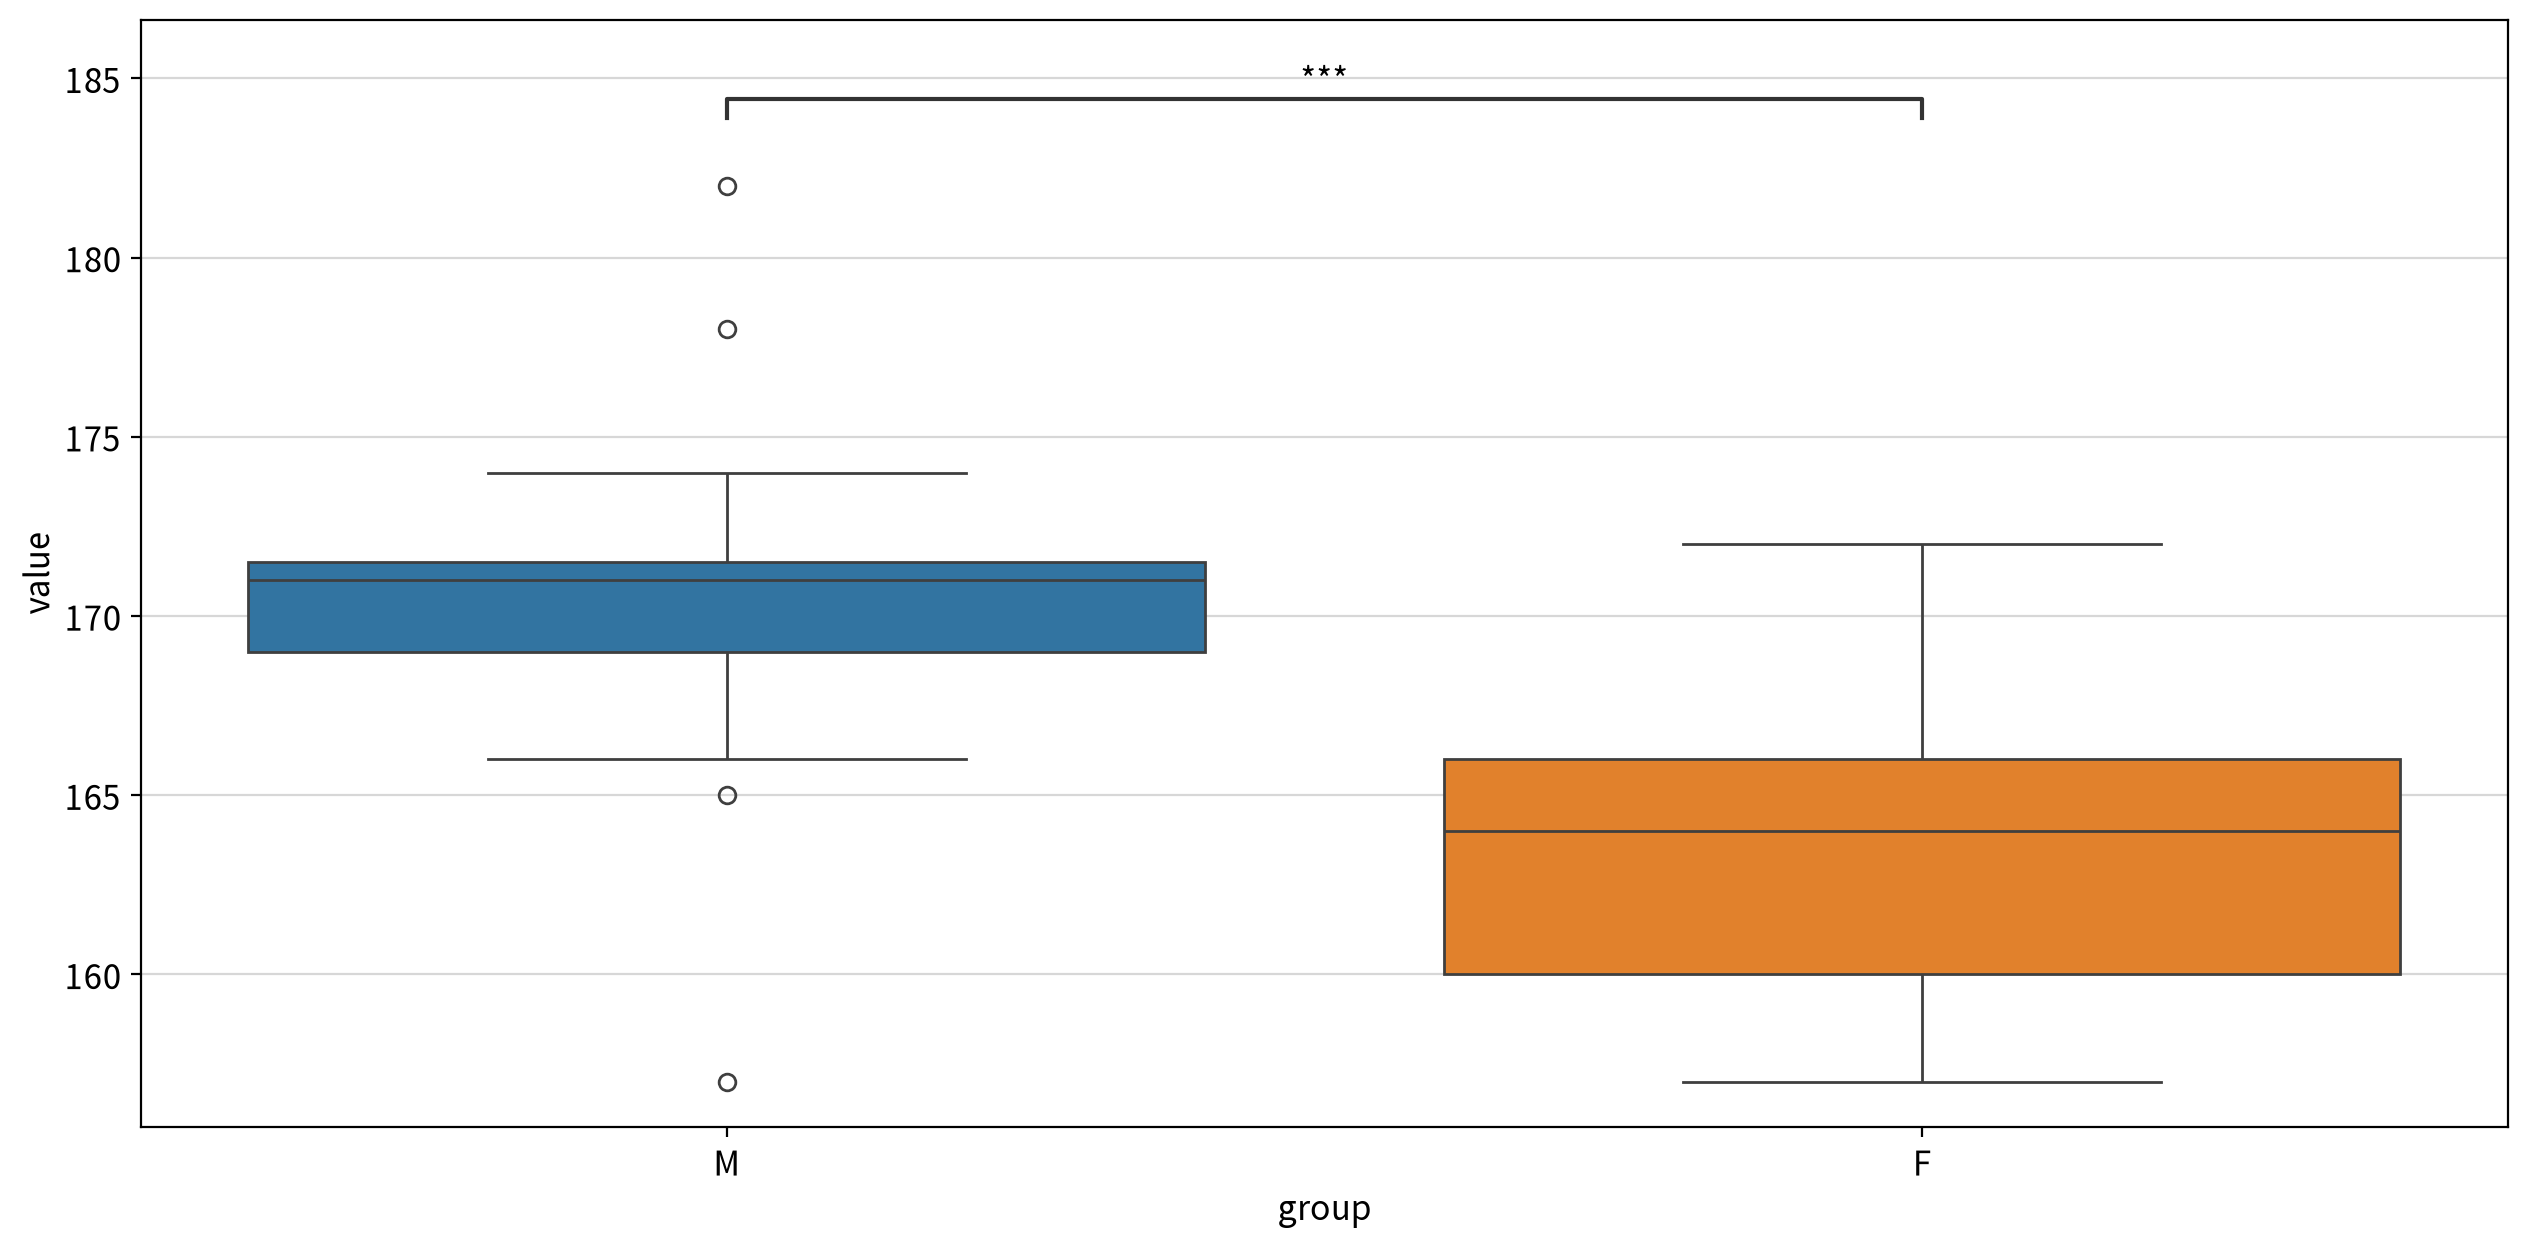

statistic  p-value  significant   result
test           alternative                                          
Student t-test two-sided        3.976    0.000         True  M =/= F
               less             3.976    1.000        False   M >= F
               greater          3.976    0.000         True    M < F

In [311]:
my_stats.test_independent(df2, "M", "F")